<a href="https://colab.research.google.com/github/sandeepa-ukr/AI-Based-Crop-Predection/blob/main/crop-yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ML imports
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
crop_files = [
    ("apples.csv", "apples"),
    ("apricots.csv", "apricots"),
    ("areca_nuts.csv", "areca nuts"),
    ("bananas.csv", "bananas"),
    ("barley.csv", "barley"),
    ("beans_dry.csv", "beans dry"),
    ("beans_green.csv", "beans green"),
    ("cabbage.csv", "cabbage"),
    ("carrots.csv", "carrots"),
    ("cashewnuts.csv", "cashewnuts"),
    ("cauliflower.csv", "cauliflower"),
    ("cherries.csv", "cherries"),
    ("chilli_dry.csv", "chilli dry"),
    ("chilli_green.csv", "chilli green"),
    ("coconuts.csv", "coconuts"),
    ("coffee.csv", "coffee"),
    ("cucumber.csv", "cucumber"),
    ("eggplant.csv", "eggplant"),
    ("fennel_coriander.csv", "fennel coriander"),
    ("garlic.csv", "garlic"),
    ("ginger.csv", "ginger"),
    ("grapes.csv", "grapes"),
    ("groundnuts.csv", "groundnuts"),
    ("lemons.csv", "lemons"),
    ("lentils.csv", "lentils"),
    ("lettuce.csv", "lettuce"),
    ("maize.csv", "maize"),
    ("mangoes.csv", "mangoes"),
    ("melons.csv", "melons"),
    ("nutmeg.csv", "nutmeg"),
    ("okra.csv", "okra"),
    ("onions.csv", "onions"),
    ("oranges.csv", "oranges"),
    ("papaya.csv", "papaya"),
    ("peaches.csv", "peaches"),
    ("pears.csv", "pears"),
    ("peas.csv", "peas"),
    ("pepper.csv", "pepper"),
    ("pineapples.csv", "pineapples"),
    ("potatoes.csv", "potatoes"),
    ("pumpkins.csv", "pumpkins"),
    ("rice.csv", "rice"),
    ("safflower.csv", "safflower"),
    ("sesame.csv", "sesame"),
    ("soyabean.csv", "soyabean"),
    ("sugarcane.csv", "sugarcane"),
    ("tomatoes.csv", "tomatoes"),
    ("watermelon.csv", "watermelon"),
    ("wheat.csv", "wheat"),
]

keep the crop name explicitly.

In [3]:
crop_dfs = []

for fname, crop_name in crop_files:
    tmp = pd.read_csv(fname)
    tmp['crop_type'] = crop_name
    crop_dfs.append(tmp)

crop_df = pd.concat(crop_dfs, ignore_index=True)

# Remove unnecessary column
if 'Flag' in crop_df.columns:
    crop_df = crop_df.drop(columns=['Flag'])

print("Crop data shape:", crop_df.shape)
print("Unique crops:", crop_df['Item'].nunique())
print("Year range:", crop_df['Year'].min(), "-", crop_df['Year'].max())

Crop data shape: (8526, 17)
Unique crops: 49
Year range: 1965 - 2022


In [4]:
# Keep only Yield rows (FAOSTAT typically also has 'Area harvested' and 'Production' as Elements)
print("Elements before filtering:", crop_df['Element'].unique())

crop_df = crop_df[crop_df['Element'].str.contains('Yield', case=False, na=False)]

print("Crop data shape after keeping only Yield rows:", crop_df.shape)
print("Elements after filtering:", crop_df['Element'].unique())

Elements before filtering: ['Area harvested' 'Yield' 'Production']
Crop data shape after keeping only Yield rows: (2842, 17)
Elements after filtering: ['Yield']


In [5]:
crop_df

,Domain Code,Domain,Area Code (FAO),Area,Element Code,Element,Item Code (FAO),Item,Year Code,Year,Unit,Value,Flag Description,Nitrogen (N) kg/ha,Phosphorus (P) kg/ha,Potassium (K) kg/ha,crop_type
58,QCL,Crops and livestock products,100,India,5419,Yield,515,Apples,1965,1965,hg/ha,41573,Calculated data,46.33,50.38,45.03,apples
59,QCL,Crops and livestock products,100,India,5419,Yield,515,Apples,1966,1966,hg/ha,41558,Calculated data,85.55,44.48,10.98,apples
60,QCL,Crops and livestock products,100,India,5419,Yield,515,Apples,1967,1967,hg/ha,41543,Calculated data,94.41,23.67,91.48,apples
61,QCL,Crops and livestock products,100,India,5419,Yield,515,Apples,1968,1968,hg/ha,41509,Calculated data,77.99,60.57,18.22,apples
62,QCL,Crops and livestock products,100,India,5419,Yield,515,Apples,1969,1969,hg/ha,41475,Calculated data,156.02,29.65,38.74,apples
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8463,QCL,Crops and livestock products,100,India,5419,Yield,15,Wheat,2018,2018,hg/ha,31457,Calculated data,160.35,68.74,78.08,wheat
8464,QCL,Crops and livestock products,100,India,5419,Yield,15,Wheat,2019,2019,hg/ha,27496,Calculated data,63.63,48.55,52.67,wheat
8465,QCL,Crops and livestock products,100,India,5419,Yield,15,Wheat,2020,2020,hg/ha,30339,Calculated data,159.55,20.72,30.32,wheat
8466,QCL,Crops and livestock products,100,India,5419,Yield,15,Wheat,2021,2021,hg/ha,31999,Calculated data,41.85,60.97,65.50,wheat


# Prepare climate data

In [6]:
rainfall = pd.read_csv('rainfall.csv')
temperature = pd.read_csv('temperature.csv')

for df in [rainfall, temperature]:
    if 'YEAR' in df.columns:
        df.rename(columns={'YEAR': 'Year'}, inplace=True)

    if 'Year' not in df.columns:
        raise ValueError("Climate files must contain a 'Year' column")

In [7]:
climate_df = pd.merge(
    rainfall,
    temperature,
    on='Year',
    how='inner'
)

print("Climate data shape:", climate_df.shape)
print(climate_df['Year'].min(), "-", climate_df['Year'].max())

Climate data shape: (58, 23)
1961 - 2018


#Create climate features

In [8]:
monthly_cols = [
    'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
    'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC'
]

In [9]:
climate_df['winter_avg'] = climate_df[
    ['DEC', 'JAN', 'FEB']
].mean(axis=1)

climate_df['summer_avg'] = climate_df[
    ['MAR', 'APR', 'MAY']
].mean(axis=1)

climate_df['monsoon_avg'] = climate_df[
    ['JUN', 'JUL', 'AUG', 'SEP']
].mean(axis=1)

climate_df['climate_std'] = climate_df[
    monthly_cols
].std(axis=1)

In [10]:
if 'ANN' in climate_df.columns:
    climate_df = climate_df.drop(columns=['ANN'])

#Create the crop-climate dataset correctly

In [11]:
yield_df = crop_df[
    crop_df['Element'].str.strip().str.lower() == 'yield'
].copy()

In [12]:
yield_df['Unit_norm'] = (
    yield_df['Unit']
    .astype(str)
    .str.strip()
    .str.lower()
)

yield_df = yield_df[
    yield_df['Unit_norm'] == 'hg/ha'
].copy()

In [13]:
print("Yield records:", len(yield_df))
print("Unique crops:", yield_df['Item'].nunique())
print("Year range:", yield_df['Year'].min(), "-", yield_df['Year'].max())

Yield records: 2842
Unique crops: 49
Year range: 1965 - 2022


In [14]:
# Display climate data info
print("Climate Data Info:")
print(climate_df.info())
print("\nFirst 5 rows of climate data:")
print(climate_df.head())

# Check for missing values
print("\nMissing values in climate data:")
print(climate_df.isnull().sum())

# Handle missing values if any
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

# Ensure Year column is integer
climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

print(f"\nCleaned climate data shape: {climate_df_clean.shape}")

Climate Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         58 non-null     int64  
 1   JAN          58 non-null     float64
 2   FEB          58 non-null     float64
 3   MAR          58 non-null     float64
 4   APR          58 non-null     float64
 5   MAY          58 non-null     float64
 6   JUN          58 non-null     float64
 7   JUL          58 non-null     float64
 8   AUG          58 non-null     float64
 9   SEP          58 non-null     float64
 10  OCT          58 non-null     float64
 11  NOV          58 non-null     float64
 12  DEC          58 non-null     float64
 13  Jan-Feb      58 non-null     float64
 14  Mar-May      58 non-null     float64
 15  Jun-Sep      58 non-null     float64
 16  Oct-Dec      58 non-null     float64
 17  ANNUAL       58 non-null     float64
 18  JAN-FEB      58 non-null     floa

In [15]:
climate_df_clean = climate_df_clean.drop(
    columns=['Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']
)

In [16]:
climate_df_clean

,Year,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,...,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC,winter_avg,summer_avg,monsoon_avg,climate_std
0,1961,26.1,34.8,26.0,28.5,77.6,192.9,336.6,287.6,234.9,...,10.4,24.00,18.98,26.11,27.06,21.17,23.766667,44.033333,263.000,116.831600
1,1962,12.6,21.6,16.0,43.6,70.8,137.1,281.6,276.9,211.0,...,29.9,24.04,18.91,25.91,27.14,21.47,21.366667,43.466667,226.650,102.202809
2,1963,6.8,9.8,41.7,50.6,60.9,168.0,258.6,316.7,164.9,...,15.5,24.15,19.07,25.57,27.21,22.04,10.700000,51.066667,227.050,103.295723
3,1964,18.6,14.1,19.0,40.0,52.1,177.2,345.7,273.7,200.4,...,13.3,24.10,18.83,26.38,26.90,21.58,15.333333,37.033333,249.250,115.764773
4,1965,11.8,28.1,26.7,45.1,52.7,116.1,270.1,192.8,129.5,...,22.2,24.07,19.22,25.24,27.08,22.10,20.700000,41.500000,177.125,82.034909
5,1966,13.1,25.4,20.3,30.6,57.2,178.8,252.5,212.5,143.9,...,16.7,24.36,19.93,26.07,27.17,21.83,18.400000,36.033333,196.925,85.149784
6,1967,11.1,14.2,63.3,29.5,42.8,144.0,305.6,264.3,170.3,...,56.1,24.11,19.44,25.55,27.19,21.68,27.133333,45.200000,221.050,101.803130
7,1968,29.4,19.8,27.5,32.6,46.7,149.6,309.9,212.8,129.5,...,12.6,23.94,18.25,25.62,27.22,21.69,20.600000,35.600000,200.450,94.076981
8,1969,12.7,14.5,20.1,39.7,63.4,130.2,317.8,273.4,172.7,...,12.7,24.46,19.18,26.39,27.35,22.20,13.300000,41.066667,223.525,105.974065
9,1970,23.2,27.3,25.9,29.2,69.7,215.9,245.6,313.0,212.7,...,1.6,24.26,19.56,26.39,27.06,21.55,17.366667,41.600000,246.800,109.732596


#Correlation-Based Feature Selection


Number of climate features: 20
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


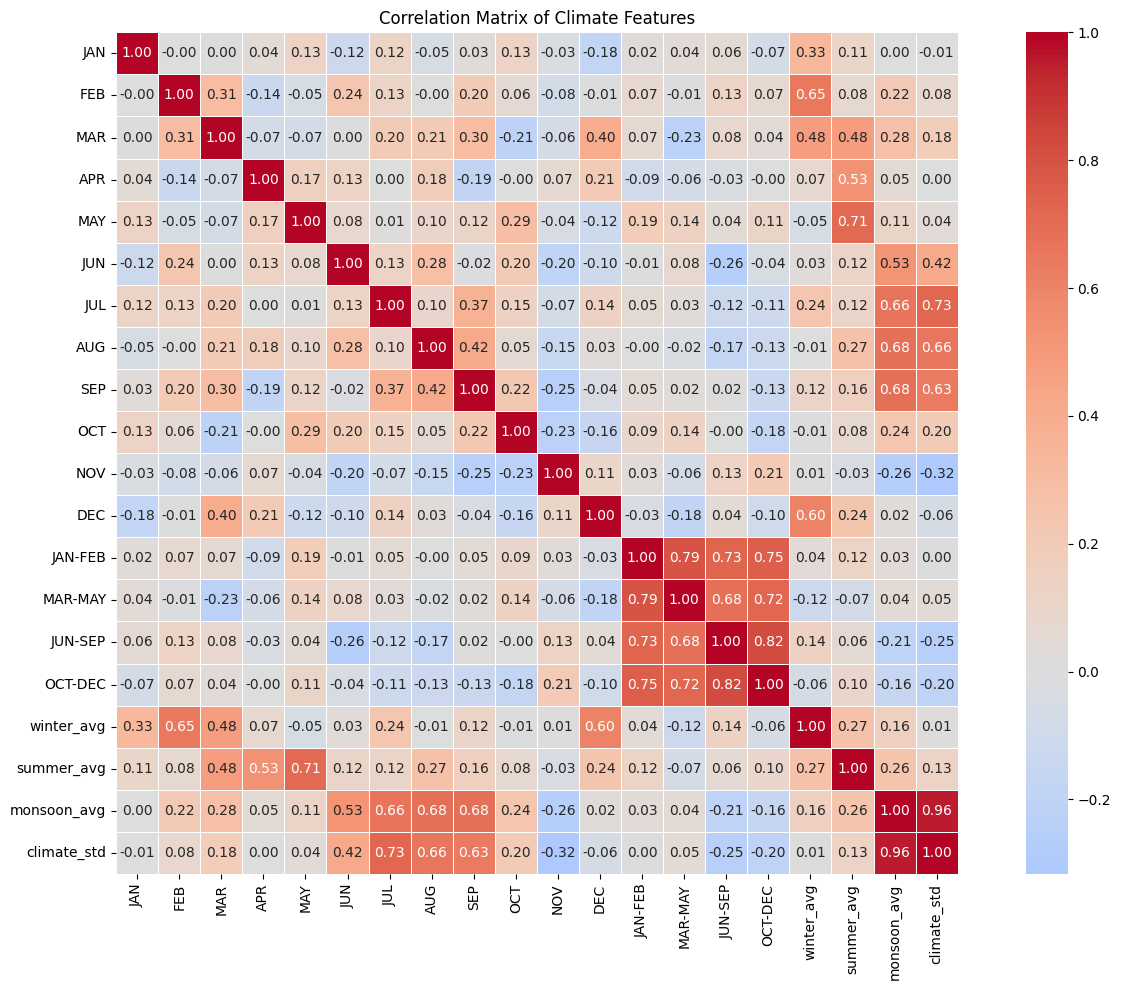


Highly correlated feature pairs (|corr| > 0.85):
     Feature 1    Feature 2  Correlation
0  monsoon_avg  climate_std     0.958369


In [17]:
# Separate features (exclude Year and any non-numeric columns)
feature_cols = [col for col in climate_df_clean.columns if col not in ['Year', 'ANNUAL']]
# Remove ANNUAL as it's already aggregated from other columns
feature_cols = [col for col in feature_cols if col != 'ANNUAL']

print(f"\nNumber of climate features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Correlation matrix
corr_matrix = climate_df_clean[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (correlation > 0.85 or < -0.85)
threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated feature pairs (|corr| > {threshold}):")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())
else:
    print("No highly correlated pairs found.")

### ===================== 1. HANDLE HIGHLY CORRELATED FEATURES =====================

In [18]:
# Your climate data
print("Original climate features:", climate_df_clean.columns.tolist())

# Identify the highly correlated features you found
high_corr_pairs = [
    ('Mar-May', 'summer_avg'),
    ('Jun-Sep', 'monsoon_avg'),
    ('Jun-Sep', 'climate_std'),
    ('monsoon_avg', 'climate_std')
]

Original climate features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']


In [19]:
# Strategy: Keep the feature with higher variance or better interpretability
def handle_correlated_features(df, corr_threshold=0.85):
    """
    Remove highly correlated features, keeping the one with higher variance
    """
    # Calculate variance for each numeric feature
    variances = df.select_dtypes(include=[np.number]).var()

    # Get correlation matrix
    corr_matrix = df.select_dtypes(include=[np.number]).corr()

    # Find pairs with correlation above threshold
    features_to_drop = set()
    correlated_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > corr_threshold:
                feat1 = corr_matrix.columns[i]
                feat2 = corr_matrix.columns[j]
                correlated_pairs.append((feat1, feat2))

                # Keep the feature with higher variance
                if variances[feat1] >= variances[feat2]:
                    features_to_drop.add(feat2)
                else:
                    features_to_drop.add(feat1)

    return features_to_drop, correlated_pairs

In [20]:
# Apply the correlation handling
features_to_drop, correlated_pairs = handle_correlated_features(
    climate_df_clean,
    corr_threshold=0.85
)

print("\nFeatures to drop due to high correlation:")
print(features_to_drop)


Features to drop due to high correlation:
{'climate_std'}


In [21]:
# Create a clean dataset without these features
climate_reduced = climate_df_clean.drop(columns=features_to_drop, errors='ignore')

print(f"\nOriginal features: {len(climate_df_clean.columns)}")
print(f"Features after removing correlated: {len(climate_reduced.columns)}")
print(f"Remaining features: {climate_reduced.columns.tolist()}")


Original features: 22
Features after removing correlated: 21
Remaining features: ['Year', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']


In [22]:
# crop_fscore= pd.read_csv('crop_fscore_merged_data.csv')

In [23]:
# # ===================== 2. UPDATED FEATURE LIST =====================

# # Get the remaining features (excluding Year and ANNUAL)
# feature_cols = [col for col in crop_fscore.columns
#                 if col not in ['Year', 'ANNUAL']]

# print(f"\nFeatures for analysis: {feature_cols}")
# print(f"Number of features: {len(feature_cols)}")

In [24]:
# ===================== 2. UPDATED FEATURE LIST =====================

# Get the remaining features (excluding Year and ANNUAL)
feature_cols = [col for col in climate_reduced.columns
                if col not in ['Year', 'ANNUAL']]

print(f"\nFeatures for analysis: {feature_cols}")
print(f"Number of features: {len(feature_cols)}")


Features for analysis: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']
Number of features: 19


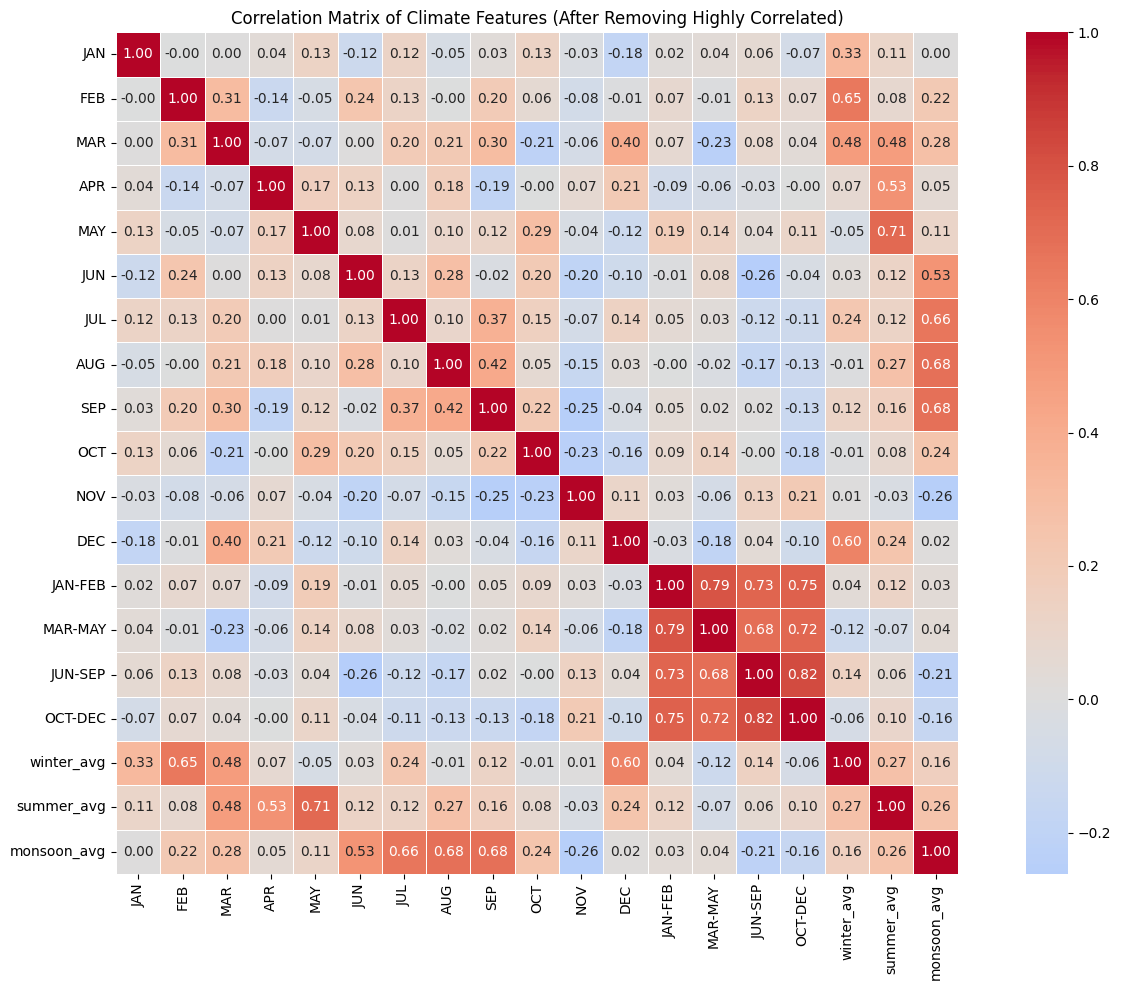

In [25]:
# ===================== 3. CORRELATION ANALYSIS WITH REMAINING FEATURES =====================

# Correlation matrix of remaining features
corr_matrix_reduced = climate_reduced[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_reduced, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix of Climate Features (After Removing Highly Correlated)')
plt.tight_layout()
plt.show()

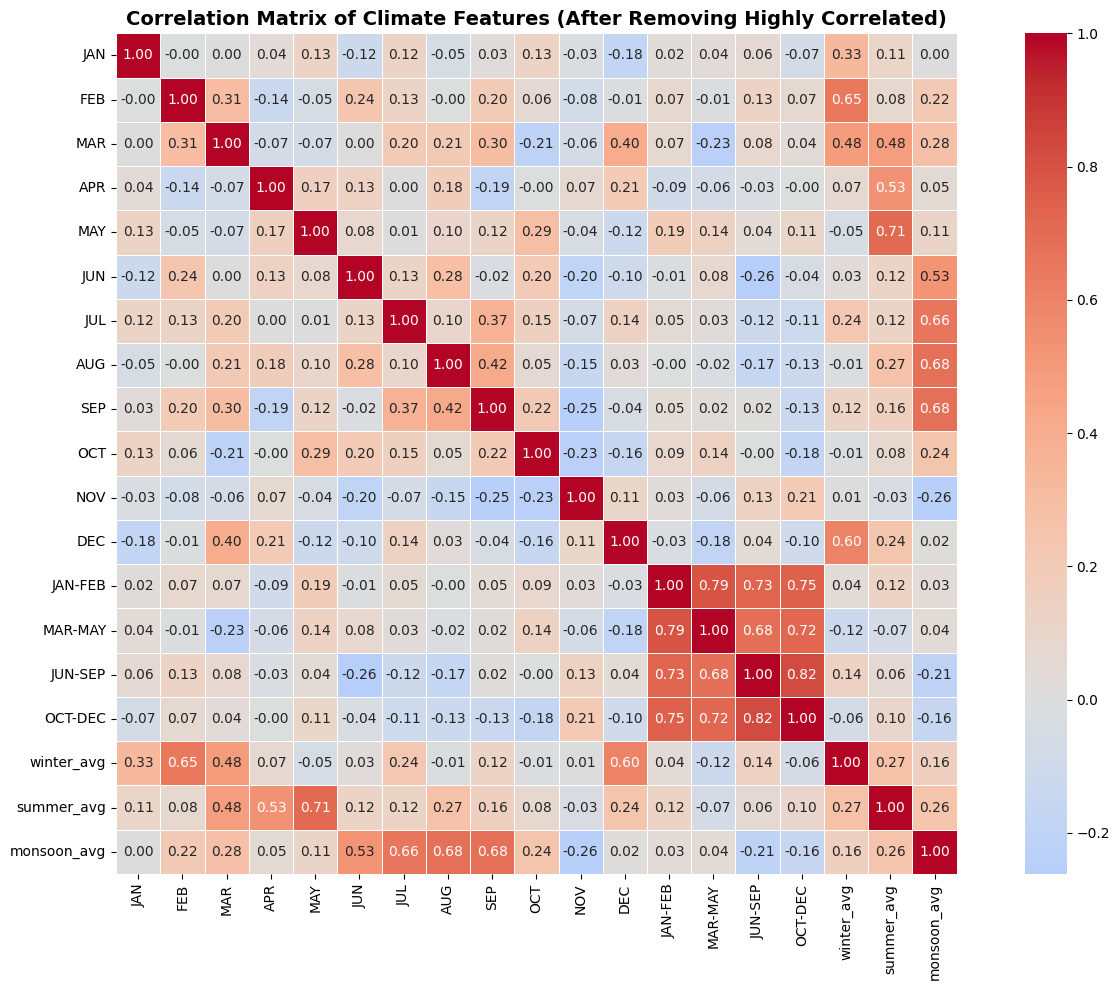

In [26]:
# ===================== 3. CORRELATION ANALYSIS WITH REMAINING FEATURES =====================

# Correlation matrix of remaining features
corr_matrix_reduced = climate_reduced[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix_reduced,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    square=True,
)

plt.title(
    'Correlation Matrix of Climate Features (After Removing Highly Correlated)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# Save figure BEFORE showing it
plt.savefig(
    'climate_correlation_matrix_reduced.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()
plt.close()

## F-SCORE ANALYSIS WITH CLEANED DATA

In [27]:
# crop_data_clean = crop_df.copy()
# crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
# crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# FTest_data = crop_data_clean.select_dtypes(include=[np.number])
# X = FTest_data.drop(columns=['target_yield'])
# y = FTest_data['target_yield']

# k = 10  # choose how many features you want
# selector = SelectKBest(score_func=f_regression, k=k)
# X_new = selector.fit_transform(X, y)

# selected_f_features = X.columns[selector.get_support()].tolist()

# print("Top", k, "features selected using F-test:")
# print(selected_f_features)

# # Keep only these features
# FTest_data = FTest_data[selected_f_features + ['target_yield']]

=== F-Score Analysis on Climate Data Only ===
Climate data shape: (58, 19)
Features: ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg']

=== F-Score Results ===
        Feature    F_Score
12      JAN-FEB  24.958914
18  monsoon_avg  22.402208
14      JUN-SEP  17.807018
15      OCT-DEC  17.579121
17   summer_avg  16.923437
13      MAR-MAY  16.267823
16   winter_avg  15.485474
3           APR  12.570868
11          DEC  12.165149
4           MAY  11.952679


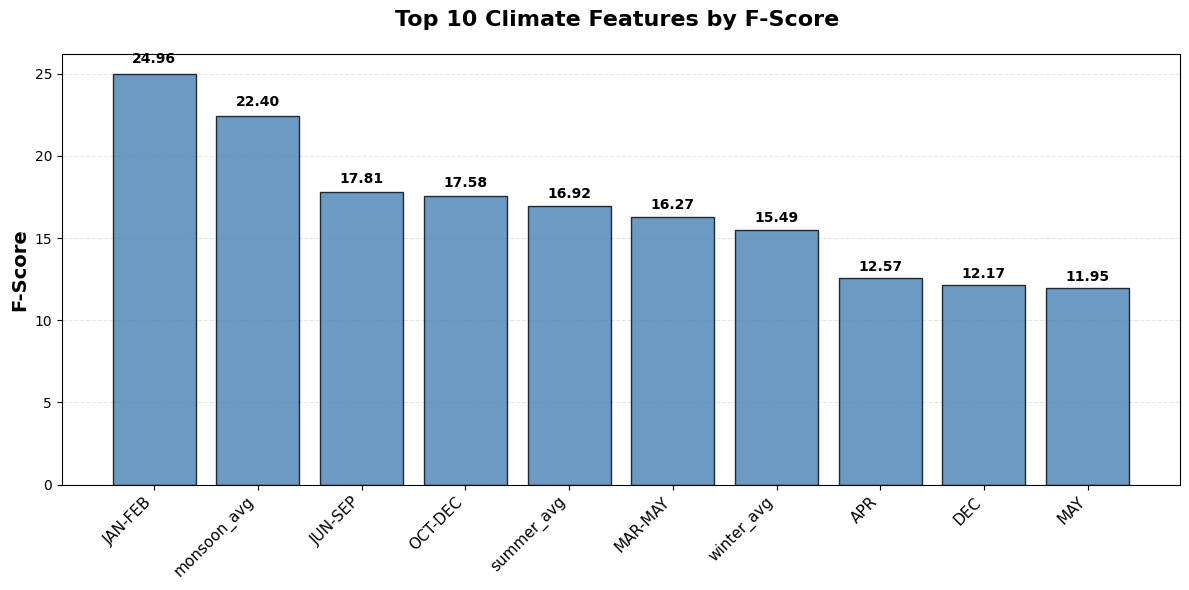


=== Detailed F-Score Analysis ===
JAN-FEB                  : F-Score = 24.9589
monsoon_avg              : F-Score = 22.4022
JUN-SEP                  : F-Score = 17.8070
OCT-DEC                  : F-Score = 17.5791
summer_avg               : F-Score = 16.9234
MAR-MAY                  : F-Score = 16.2678
winter_avg               : F-Score = 15.4855
APR                      : F-Score = 12.5709
DEC                      : F-Score = 12.1651
MAY                      : F-Score = 11.9527


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

# ===================== F-SCORE ANALYSIS ON CLIMATE DATA ONLY =====================

# Assuming 'climate_reduced' is your climate dataset
print("=== F-Score Analysis on Climate Data Only ===")


# Copy climate data
climate_data = climate_reduced.copy()
climate_features = climate_data.drop(
    columns=['Year', 'ANNUAL'],
    errors='ignore'
)


# Keep only numeric columns
numeric_cols = climate_features.select_dtypes(include=[np.number]).columns
climate_features = climate_features[numeric_cols]

print(f"Climate data shape: {climate_features.shape}")
print(f"Features: {climate_features.columns.tolist()}")

# Handle missing values
climate_features = climate_features.fillna(climate_features.mean())

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(climate_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=climate_features.columns)

# ===================== F-SCORE USING PCA COMPONENTS =====================

# Use PCA to create pseudo-targets
n_components = min(5, X_scaled.shape[1])  # Use 5 PCA components
pca = PCA(n_components=n_components)
pca_scores = pca.fit_transform(X_scaled)

# Calculate F-scores for each feature against each PCA component
all_f_scores = []

for i in range(n_components):
    # F-test between features and PCA component
    f_scores, p_values = f_regression(X_scaled, pca_scores[:, i])
    all_f_scores.append(f_scores)

# Calculate average F-score across all PCA components
avg_f_scores = np.mean(all_f_scores, axis=0)

# Create final F-score DataFrame
f_score_df = pd.DataFrame({
    'Feature': climate_features.columns,
    'F_Score': avg_f_scores
}).sort_values('F_Score', ascending=False)

print("\n=== F-Score Results ===")
print(f_score_df.head(10))

# ===================== F-SCORE BAR CHART =====================

# Plot F-scores
plt.figure(figsize=(12, 6))
bars = plt.bar(f_score_df['Feature'].head(10), f_score_df['F_Score'].head(10),
               color='steelblue', alpha=0.8, edgecolor='black')

# Customize the plot
# plt.xlabel("Climate Features", fontsize=14, fontweight='bold')
plt.ylabel("F-Score", fontsize=14, fontweight='bold')
plt.title("Top 10 Climate Features by F-Score ",
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.show()

# Print feature details
print("\n=== Detailed F-Score Analysis ===")
for i, row in f_score_df.head(10).iterrows():
    print(f"{row['Feature']:25s}: F-Score = {row['F_Score']:.4f}")

In [29]:
# ============================================================
# CORRELATION-BASED FEATURE SELECTION FOR CLIMATE DATA
# ============================================================

# 1. Select numerical climate features
climate_numeric = climate_df.select_dtypes(include=[np.number]).copy()

# Remove Year because it is a time identifier, not a climate variable
if 'Year' in climate_numeric.columns:
    climate_numeric = climate_numeric.drop(columns=['Year'])

print("Original climate features:")
print(climate_numeric.columns.tolist())
print("Number of features:", len(climate_numeric.columns))




Original climate features:
['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'ANNUAL', 'JAN-FEB', 'MAR-MAY', 'JUN-SEP', 'OCT-DEC', 'winter_avg', 'summer_avg', 'monsoon_avg', 'climate_std']
Number of features: 25


COMPLETE DATASET SHAPE:
Total samples: 2646
Total features: 29
Years covered: 1965 - 2018
Crops covered: 49

First few rows:
   Year    Item  Value crop_type   JAN   FEB   MAR   APR   MAY    JUN  ...  \
0  1965  Apples  41573    apples  11.8  28.1  26.7  45.1  52.7  116.1  ...   
1  1966  Apples  41558    apples  13.1  25.4  20.3  30.6  57.2  178.8  ...   
2  1967  Apples  41543    apples  11.1  14.2  63.3  29.5  42.8  144.0  ...   
3  1968  Apples  41509    apples  29.4  19.8  27.5  32.6  46.7  149.6  ...   
4  1969  Apples  41475    apples  12.7  14.5  20.1  39.7  63.4  130.2  ...   

   Oct-Dec  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  winter_avg  \
0     74.4   24.07    19.22    25.24    27.08    22.10   20.700000   
1    123.7   24.36    19.93    26.07    27.17    21.83   18.400000   
2    108.9   24.11    19.44    25.55    27.19    21.68   27.133333   
3    101.6   23.94    18.25    25.62    27.22    21.69   20.600000   
4    103.4   24.46    19.18    26.39    27.35    22.20  

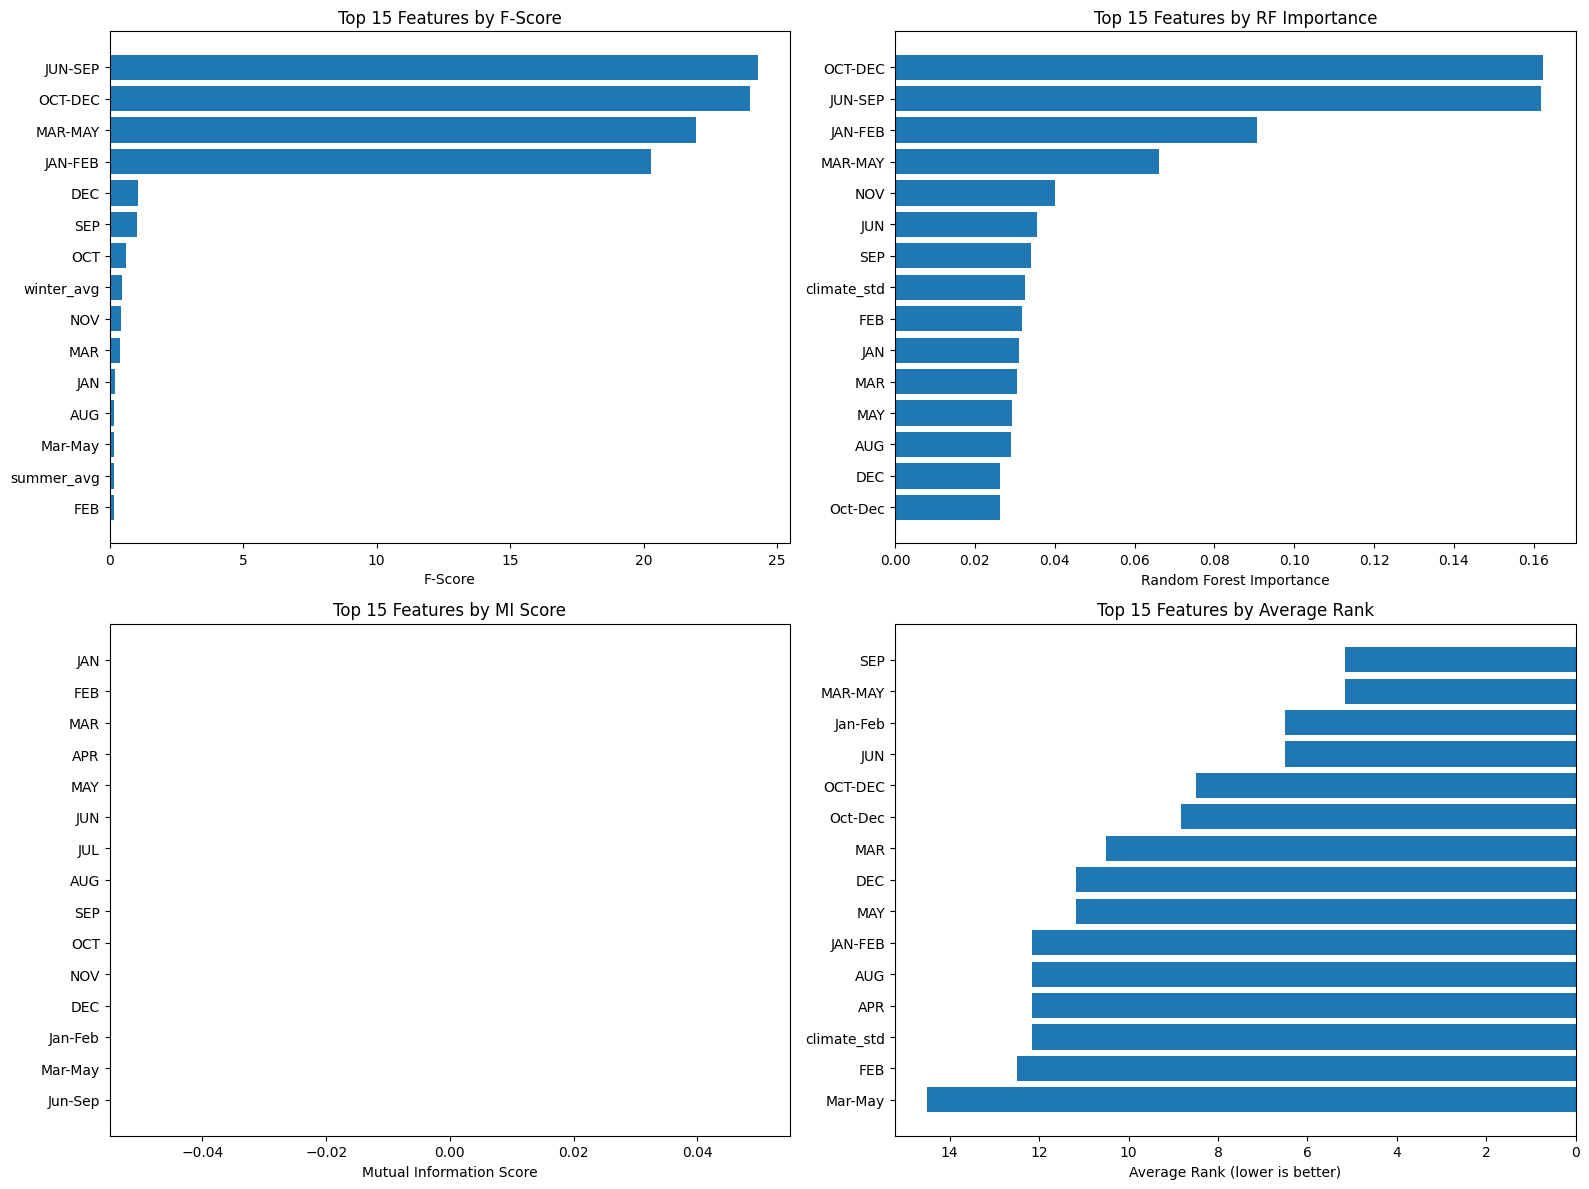

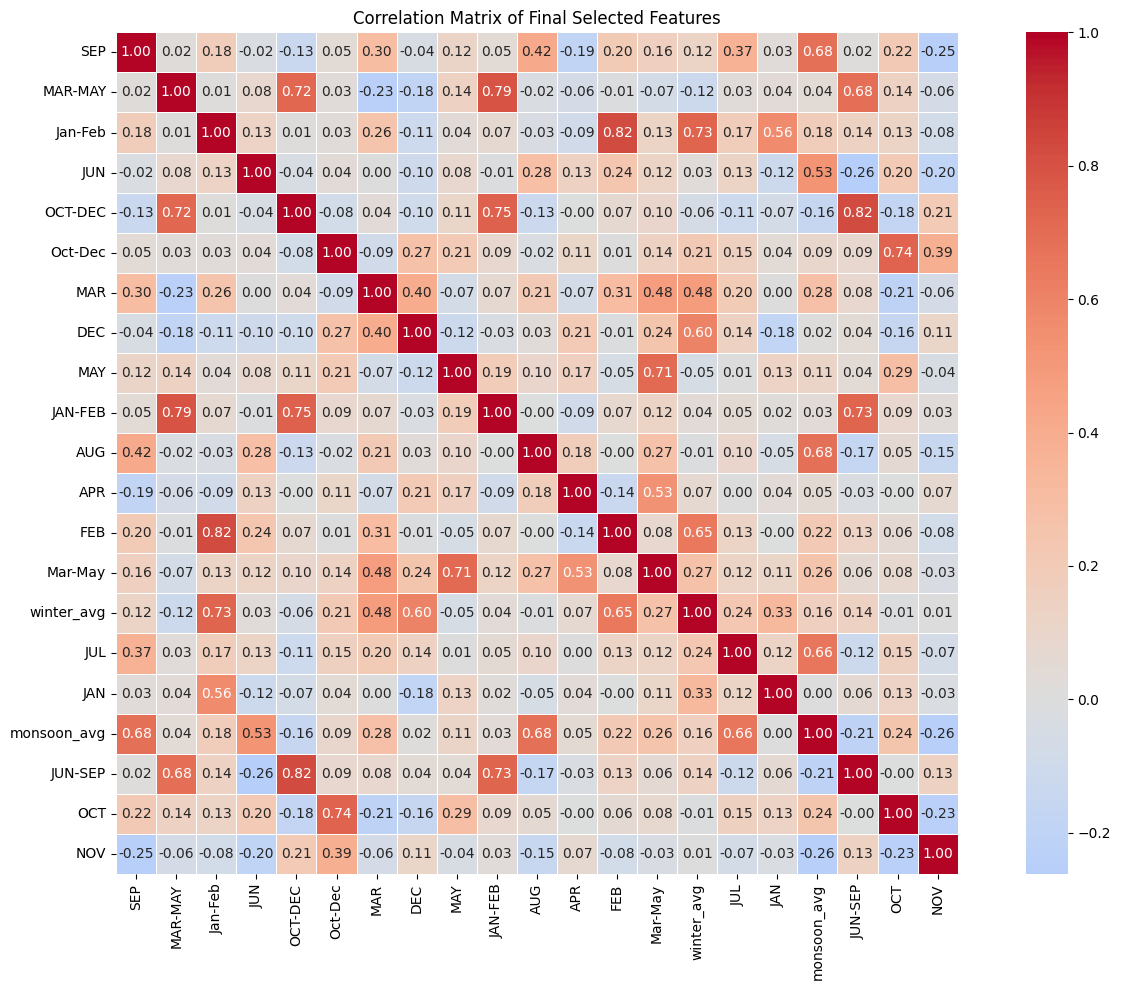


SUMMARY REPORT
Total climate features: 24
Features after correlation selection: 21
Features after F-score selection: 6
Features after RF importance: 6
Features after MI selection: 24
Final selected features: 21
Feature reduction: 3 (12.5%)

Final features: ['SEP', 'MAR-MAY', 'Jan-Feb', 'JUN', 'OCT-DEC', 'Oct-Dec', 'MAR', 'DEC', 'MAY', 'JAN-FEB', 'AUG', 'APR', 'FEB', 'Mar-May', 'winter_avg', 'JUL', 'JAN', 'monsoon_avg', 'JUN-SEP', 'OCT', 'NOV']

✅ Feature selection completed successfully!


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. PREPARE COMPLETE DATASET =====================

# Clean climate data
climate_df_clean = climate_df.copy()
for col in climate_df_clean.columns:
    if climate_df_clean[col].dtype in ['float64', 'int64']:
        climate_df_clean[col] = climate_df_clean[col].fillna(climate_df_clean[col].mean())

climate_df_clean['Year'] = climate_df_clean['Year'].astype(int)

# Clean crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Value', 'crop_type']].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

# Merge complete dataset (all crops with all climate data)
complete_data = pd.merge(
    crop_data_clean,
    climate_df_clean,
    on='Year',
    how='inner'
)

print("COMPLETE DATASET SHAPE:")
print(f"Total samples: {complete_data.shape[0]}")
print(f"Total features: {complete_data.shape[1]}")
print(f"Years covered: {complete_data['Year'].min()} - {complete_data['Year'].max()}")
print(f"Crops covered: {complete_data['crop_type'].nunique()}")
print(f"\nFirst few rows:")
print(complete_data.head())

# ===================== 2. FEATURE SELECTION ON COMPLETE DATASET =====================

# Define features (exclude non-numeric columns)
exclude_cols = ['Year', 'Item', 'crop_type', 'Value', 'Flag', 'Flag Description',
                'Domain Code', 'Domain', 'Area Code (FAO)', 'Area', 'Element Code',
                'Element', 'Item Code (FAO)', 'Unit', 'ANNUAL']  # Exclude aggregate columns

# Get all climate feature columns
all_features = [col for col in complete_data.columns
                if col not in exclude_cols and complete_data[col].dtype in ['float64', 'int64']]

print(f"\nTotal climate features: {len(all_features)}")
print(f"Features: {all_features}")

# Prepare X (features) and y (target - crop yield)
X_complete = complete_data[all_features]
y_complete = complete_data['Value']

# Handle any missing values
X_complete = X_complete.fillna(X_complete.mean())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_complete)
X_scaled_df = pd.DataFrame(X_scaled, columns=all_features)

print(f"\nX shape: {X_scaled_df.shape}")
print(f"y shape: {y_complete.shape}")

# ===================== 3. METHOD 1: CORRELATION-BASED SELECTION =====================

print("\n" + "="*60)
print("METHOD 1: CORRELATION-BASED FEATURE SELECTION")
print("="*60)

# Calculate correlation matrix
corr_matrix = X_scaled_df.corr()

# Find highly correlated features (|corr| > 0.85)
corr_threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

print(f"\nHighly correlated pairs found: {len(high_corr_pairs)}")
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string())

# Select features by removing highly correlated ones
# Strategy: Keep feature with higher correlation with target (y)
target_corr = pd.Series([abs(X_scaled_df[col].corr(y_complete)) for col in X_scaled_df.columns],
                        index=X_scaled_df.columns)

features_to_drop = set()
for pair in high_corr_pairs:
    feat1, feat2 = pair['Feature 1'], pair['Feature 2']
    # Keep feature with higher correlation with target
    if target_corr[feat1] >= target_corr[feat2]:
        features_to_drop.add(feat2)
    else:
        features_to_drop.add(feat1)

correlation_selected = [f for f in all_features if f not in features_to_drop]

print(f"\nCorrelation-based selected features: {len(correlation_selected)}")
print(f"Features selected: {correlation_selected}")

# ===================== 4. METHOD 2: F-SCORE (ANOVA) SELECTION =====================

print("\n" + "="*60)
print("METHOD 2: F-SCORE FEATURE SELECTION")
print("="*60)

# Apply F-score on complete dataset
f_selector = SelectKBest(score_func=f_regression, k='all')
f_selector.fit(X_scaled_df, y_complete)

# Get F-scores
f_scores = pd.DataFrame({
    'Feature': all_features,
    'F_Score': f_selector.scores_,
    'p_value': f_selector.pvalues_
})
f_scores = f_scores.sort_values('F_Score', ascending=False)

print("\nTop 15 features by F-score:")
print(f_scores.head(15))

# Select top N features by F-score
f_score_threshold = f_scores['F_Score'].quantile(0.75)  # Top 25%
fscore_selected = f_scores[f_scores['F_Score'] >= f_score_threshold]['Feature'].tolist()

print(f"\nF-score selected features (top 25%): {len(fscore_selected)}")
print(f"Features: {fscore_selected}")

# ===================== 5. METHOD 3: RANDOM FOREST FEATURE IMPORTANCE =====================

print("\n" + "="*60)
print("METHOD 3: RANDOM FOREST FEATURE IMPORTANCE")
print("="*60)

# Train Random Forest on complete dataset
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled_df, y_complete)

# Get feature importances
rf_importance = pd.DataFrame({
    'Feature': all_features,
    'RF_Importance': rf.feature_importances_
})
rf_importance = rf_importance.sort_values('RF_Importance', ascending=False)

print("\nTop 15 features by Random Forest importance:")
print(rf_importance.head(15))

# Select features with importance above threshold
rf_threshold = rf_importance['RF_Importance'].quantile(0.75)  # Top 25%
rf_selected = rf_importance[rf_importance['RF_Importance'] >= rf_threshold]['Feature'].tolist()

print(f"\nRandom Forest selected features (top 25%): {len(rf_selected)}")
print(f"Features: {rf_selected}")

# ===================== 6. METHOD 4: MUTUAL INFORMATION =====================

print("\n" + "="*60)
print("METHOD 4: MUTUAL INFORMATION FEATURE SELECTION")
print("="*60)

# Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_regression, k='all')
mi_selector.fit(X_scaled_df, y_complete)

mi_scores = pd.DataFrame({
    'Feature': all_features,
    'MI_Score': mi_selector.scores_
})
mi_scores = mi_scores.sort_values('MI_Score', ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_scores.head(15))

# Select top features by MI
mi_threshold = mi_scores['MI_Score'].quantile(0.75)
mi_selected = mi_scores[mi_scores['MI_Score'] >= mi_threshold]['Feature'].tolist()

print(f"\nMutual Information selected features (top 25%): {len(mi_selected)}")
print(f"Features: {mi_selected}")

# ===================== 7. COMPARE ALL METHODS =====================

print("\n" + "="*60)
print("COMPARISON OF FEATURE SELECTION METHODS")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': all_features,
    'F_Score': f_scores.set_index('Feature')['F_Score'],
    'RF_Importance': rf_importance.set_index('Feature')['RF_Importance'],
    'MI_Score': mi_scores.set_index('Feature')['MI_Score']
})

# Add selection status
comparison_df['Correlation_Selected'] = comparison_df['Feature'].isin(correlation_selected)
comparison_df['FScore_Selected'] = comparison_df['Feature'].isin(fscore_selected)
comparison_df['RF_Selected'] = comparison_df['Feature'].isin(rf_selected)
comparison_df['MI_Selected'] = comparison_df['Feature'].isin(mi_selected)

# Calculate rank for each method
comparison_df['F_Rank'] = comparison_df['F_Score'].rank(ascending=False)
comparison_df['RF_Rank'] = comparison_df['RF_Importance'].rank(ascending=False)
comparison_df['MI_Rank'] = comparison_df['MI_Score'].rank(ascending=False)
comparison_df['Avg_Rank'] = comparison_df[['F_Rank', 'RF_Rank', 'MI_Rank']].mean(axis=1)

# Sort by average rank
comparison_df = comparison_df.sort_values('Avg_Rank')

print("\nFeature rankings (lower rank = better):")
print(comparison_df[['Feature', 'F_Rank', 'RF_Rank', 'MI_Rank', 'Avg_Rank']].head(20))

# ===================== 8. CONSENSUS FEATURE SELECTION =====================

print("\n" + "="*60)
print("CONSENSUS FEATURE SELECTION")
print("="*60)

# Method A: Features selected by at least 2 methods
selected_by_multiple = comparison_df[
    (comparison_df['FScore_Selected'] & comparison_df['RF_Selected']) |
    (comparison_df['FScore_Selected'] & comparison_df['MI_Selected']) |
    (comparison_df['RF_Selected'] & comparison_df['MI_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['FScore_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['RF_Selected']) |
    (comparison_df['Correlation_Selected'] & comparison_df['MI_Selected'])
]['Feature'].tolist()

print(f"\nFeatures selected by at least 2 methods: {len(selected_by_multiple)}")
print(f"Features: {selected_by_multiple}")

# Method B: Features selected by all 3 methods (F-score, RF, MI)
selected_by_all = comparison_df[
    comparison_df['FScore_Selected'] &
    comparison_df['RF_Selected'] &
    comparison_df['MI_Selected']
]['Feature'].tolist()

print(f"\nFeatures selected by all 3 methods (F-score, RF, MI): {len(selected_by_all)}")
print(f"Features: {selected_by_all}")

# Method C: Top N features by average rank
top_n_by_rank = comparison_df.head(15)['Feature'].tolist()
print(f"\nTop 15 features by average rank: {len(top_n_by_rank)}")
print(f"Features: {top_n_by_rank}")

# ===================== 9. FINAL SELECTION =====================

# Use consensus selection (features selected by at least 2 methods)
final_selected_features = selected_by_multiple

# If too few features, use top features by rank
if len(final_selected_features) < 10:
    final_selected_features = top_n_by_rank
    print(f"\nUsing top {len(final_selected_features)} features by rank")

# If still too few, use union of all methods
if len(final_selected_features) < 10:
    final_selected_features = list(set(correlation_selected) |
                                  set(fscore_selected) |
                                  set(rf_selected) |
                                  set(mi_selected))
    print(f"\nUsing union of all methods: {len(final_selected_features)} features")

print(f"\nFINAL SELECTED FEATURES: {len(final_selected_features)}")
print(f"Features: {final_selected_features}")

# ===================== 10. CREATE FINAL DATASET =====================

# Create final climate dataset with selected features
climate_final = climate_df_clean[['Year'] + final_selected_features].copy()

# Save
climate_final.to_csv('climate_data_final_selected_features.csv', index=False)
print(f"\nFinal dataset saved to 'climate_data_final_selected_features.csv'")
print(f"Shape: {climate_final.shape}")

# ===================== 11. VALIDATION =====================

print("\n" + "="*60)
print("VALIDATION OF SELECTED FEATURES")
print("="*60)

# Compare model performance with all features vs selected features
def evaluate_features(features, X, y):
    X_subset = X[features]
    lr = LinearRegression()
    scores = cross_val_score(lr, X_subset, y, cv=5, scoring='r2')
    return scores.mean(), scores.std()

# Use the scaled complete dataset
print("\nModel performance (R² score with 5-fold CV):")

# All features
all_score, all_std = evaluate_features(all_features, X_scaled_df, y_complete)
print(f"All features ({len(all_features)}): {all_score:.4f} ± {all_std:.4f}")

# Final selected features
final_score, final_std = evaluate_features(final_selected_features, X_scaled_df, y_complete)
print(f"Selected features ({len(final_selected_features)}): {final_score:.4f} ± {final_std:.4f}")

# Improvement
improvement = ((final_score - all_score) / abs(all_score)) * 100
print(f"Performance change: {improvement:.2f}%")

# ===================== 12. VISUALIZATIONS =====================

# Plot feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F-scores
axes[0, 0].barh(f_scores.head(15)['Feature'], f_scores.head(15)['F_Score'])
axes[0, 0].set_xlabel('F-Score')
axes[0, 0].set_title('Top 15 Features by F-Score')
axes[0, 0].invert_yaxis()

# 2. RF Importance
axes[0, 1].barh(rf_importance.head(15)['Feature'], rf_importance.head(15)['RF_Importance'])
axes[0, 1].set_xlabel('Random Forest Importance')
axes[0, 1].set_title('Top 15 Features by RF Importance')
axes[0, 1].invert_yaxis()

# 3. MI Scores
axes[1, 0].barh(mi_scores.head(15)['Feature'], mi_scores.head(15)['MI_Score'])
axes[1, 0].set_xlabel('Mutual Information Score')
axes[1, 0].set_title('Top 15 Features by MI Score')
axes[1, 0].invert_yaxis()

# 4. Average Rank
top_ranked = comparison_df.head(15)
axes[1, 1].barh(top_ranked['Feature'], top_ranked['Avg_Rank'])
axes[1, 1].set_xlabel('Average Rank (lower is better)')
axes[1, 1].set_title('Top 15 Features by Average Rank')
axes[1, 1].invert_xaxis()
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Correlation heatmap of final features
if len(final_selected_features) > 1:
    plt.figure(figsize=(14, 10))
    final_corr = climate_final[final_selected_features].corr()
    sns.heatmap(final_corr, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', linewidths=0.5, square=True)
    plt.title('Correlation Matrix of Final Selected Features')
    plt.tight_layout()
    plt.show()

# ===================== 13. SUMMARY REPORT =====================

print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)
print(f"Total climate features: {len(all_features)}")
print(f"Features after correlation selection: {len(correlation_selected)}")
print(f"Features after F-score selection: {len(fscore_selected)}")
print(f"Features after RF importance: {len(rf_selected)}")
print(f"Features after MI selection: {len(mi_selected)}")
print(f"Final selected features: {len(final_selected_features)}")
print(f"Feature reduction: {len(all_features) - len(final_selected_features)} ({((len(all_features) - len(final_selected_features))/len(all_features)*100):.1f}%)")
print(f"\nFinal features: {final_selected_features}")

print("\n✅ Feature selection completed successfully!")

F-score selected features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

Climate data with F-score selected features:
   Year    SEP  MAR-MAY  Jan-Feb    JUN  OCT-DEC  Oct-Dec   MAR   DEC   MAY  \
0  1961  234.9    26.11     60.9  192.9    21.17    154.2  26.0  10.4  77.6   
1  1962  211.0    25.91     34.3  137.1    21.47    126.7  16.0  29.9  70.8   
2  1963  164.9    25.57     16.6  168.0    22.04    142.9  41.7  15.5  60.9   
3  1964  200.4    26.38     32.7  177.2    21.58    103.5  19.0  13.3  52.1   
4  1965  129.5    25.24     39.9  116.1    22.10     74.4  26.7  22.2  52.7   

   ...   APR   FEB  Mar-May  winter_avg    JUL   JAN  monsoon_avg  JUN-SEP  \
0  ...  28.5  34.8    132.1   23.766667  336.6  26.1      263.000    27.06   
1  ...  43.6  21.6    130.4   21.366667  281.6  12.6      226.650    27.14   
2  ...  50.6   9.8    153.1   10.700000  258.6   6.8      227.050    27.21   
3  ...  40.0  14.1    111.1   15.333333  345.7  18.6      249.250    26.90   
4  

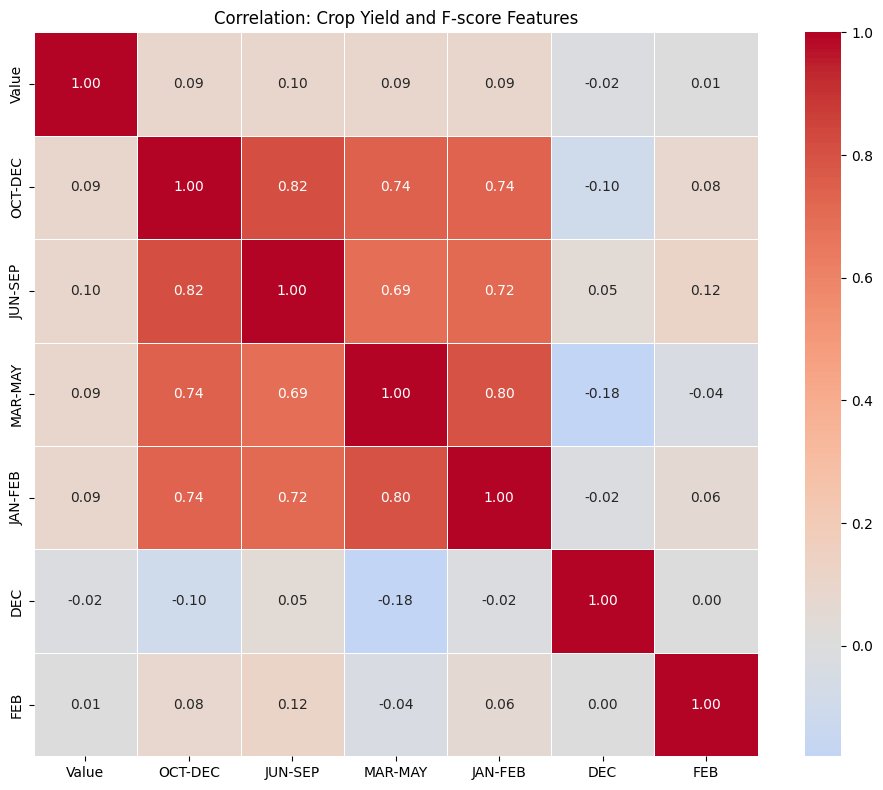

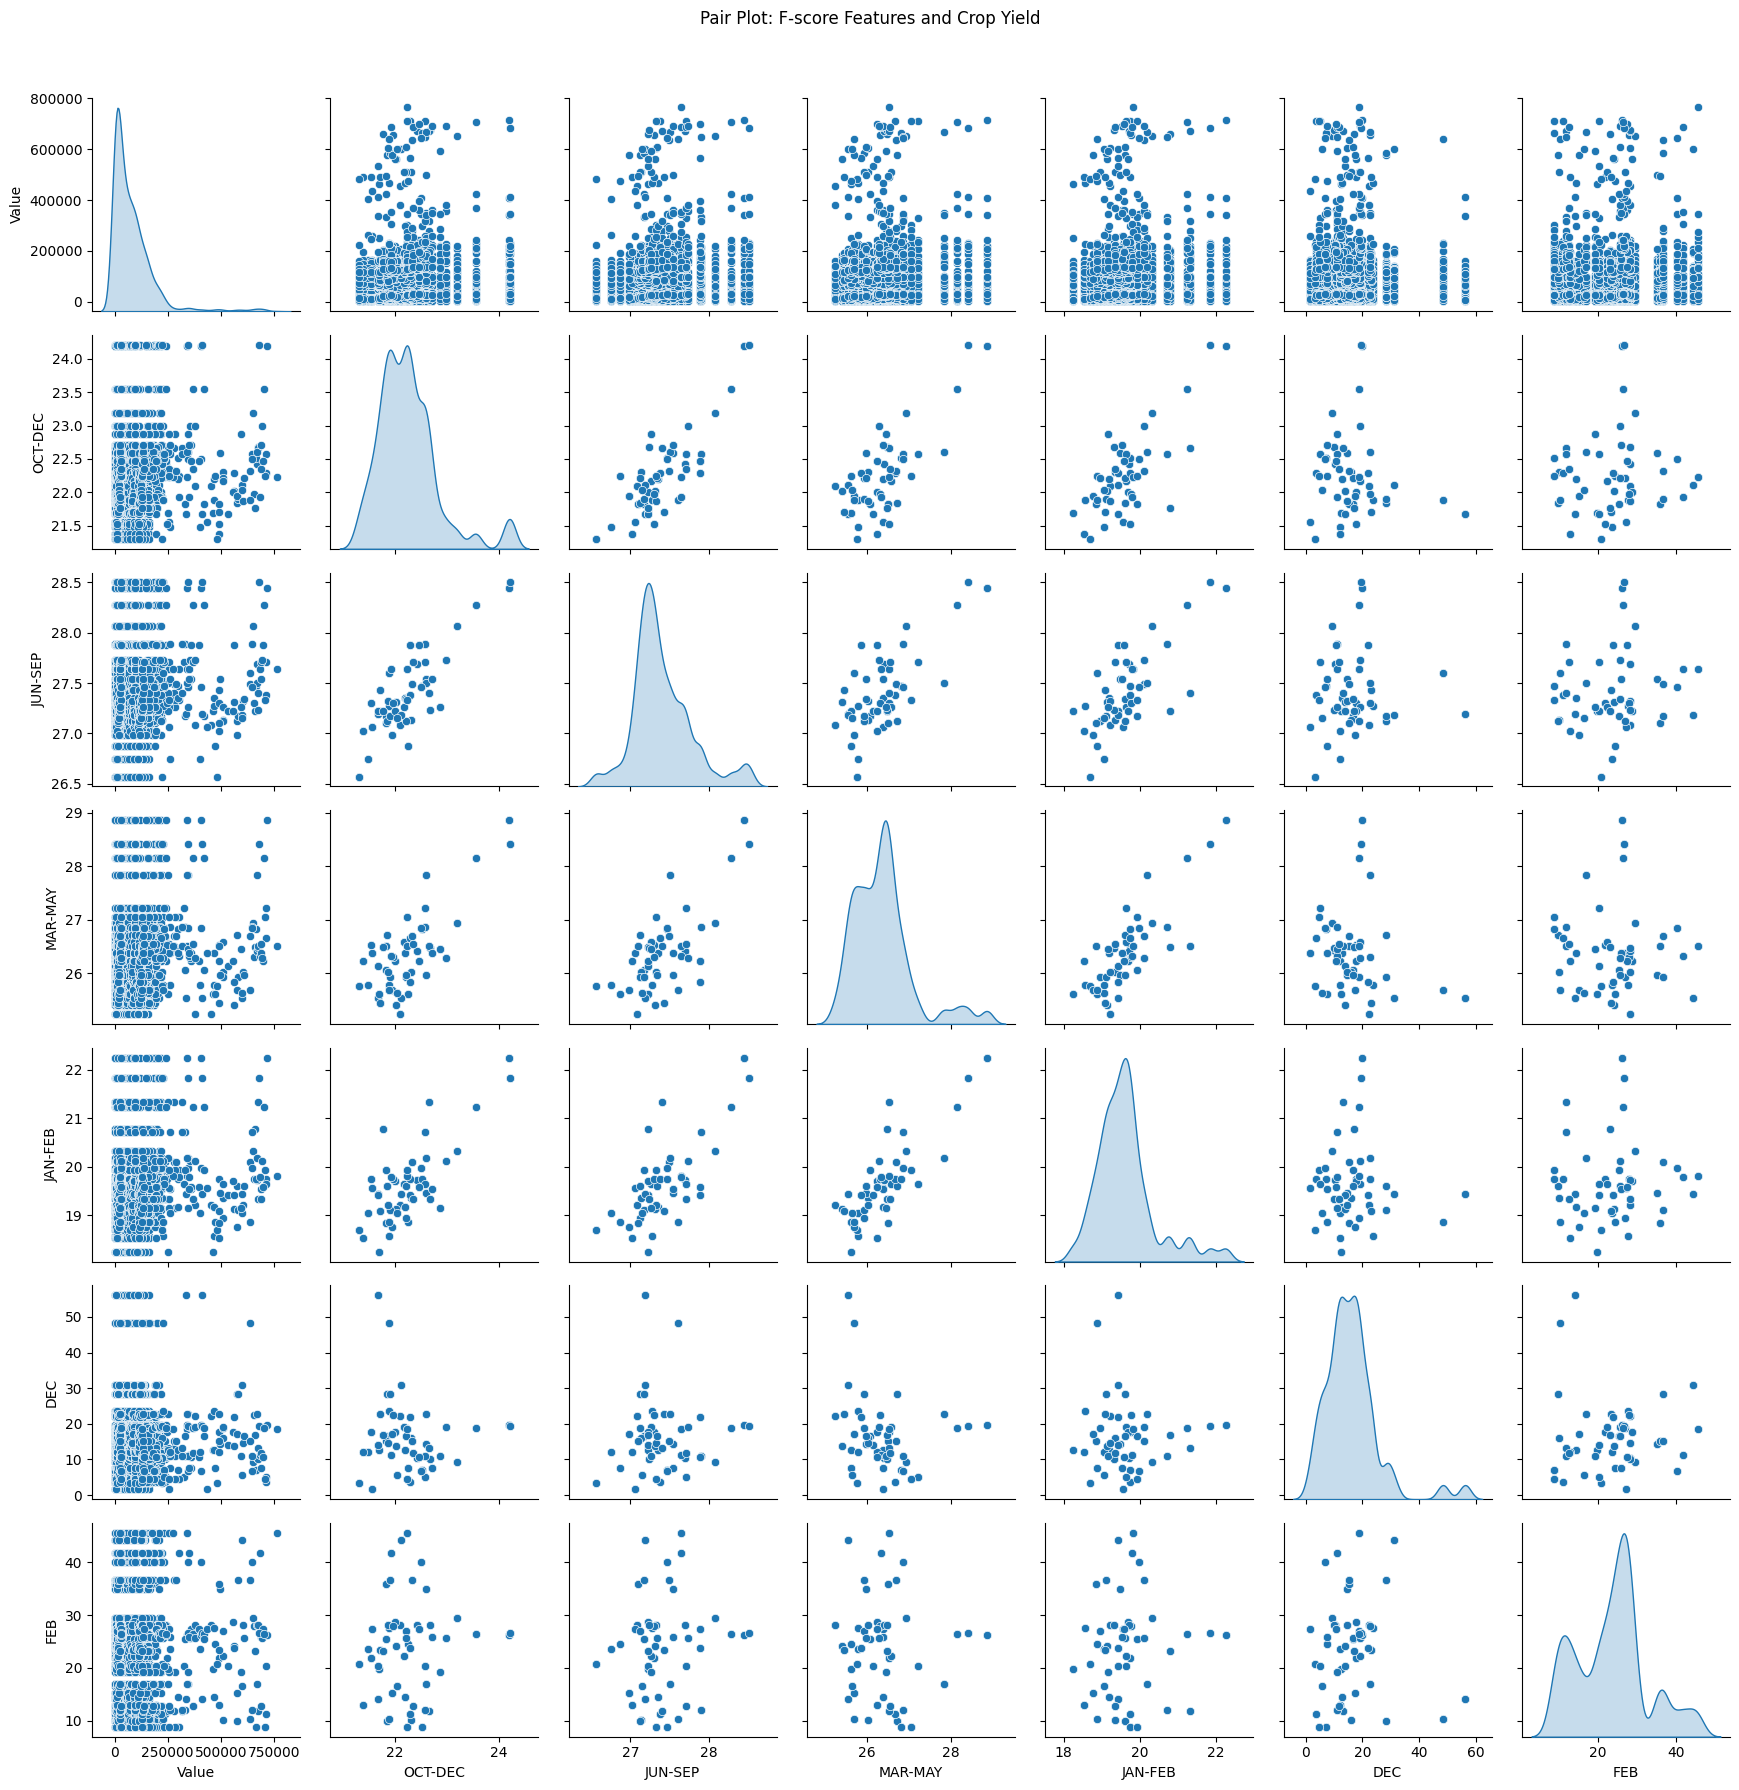


FEATURE DISTRIBUTION ANALYSIS


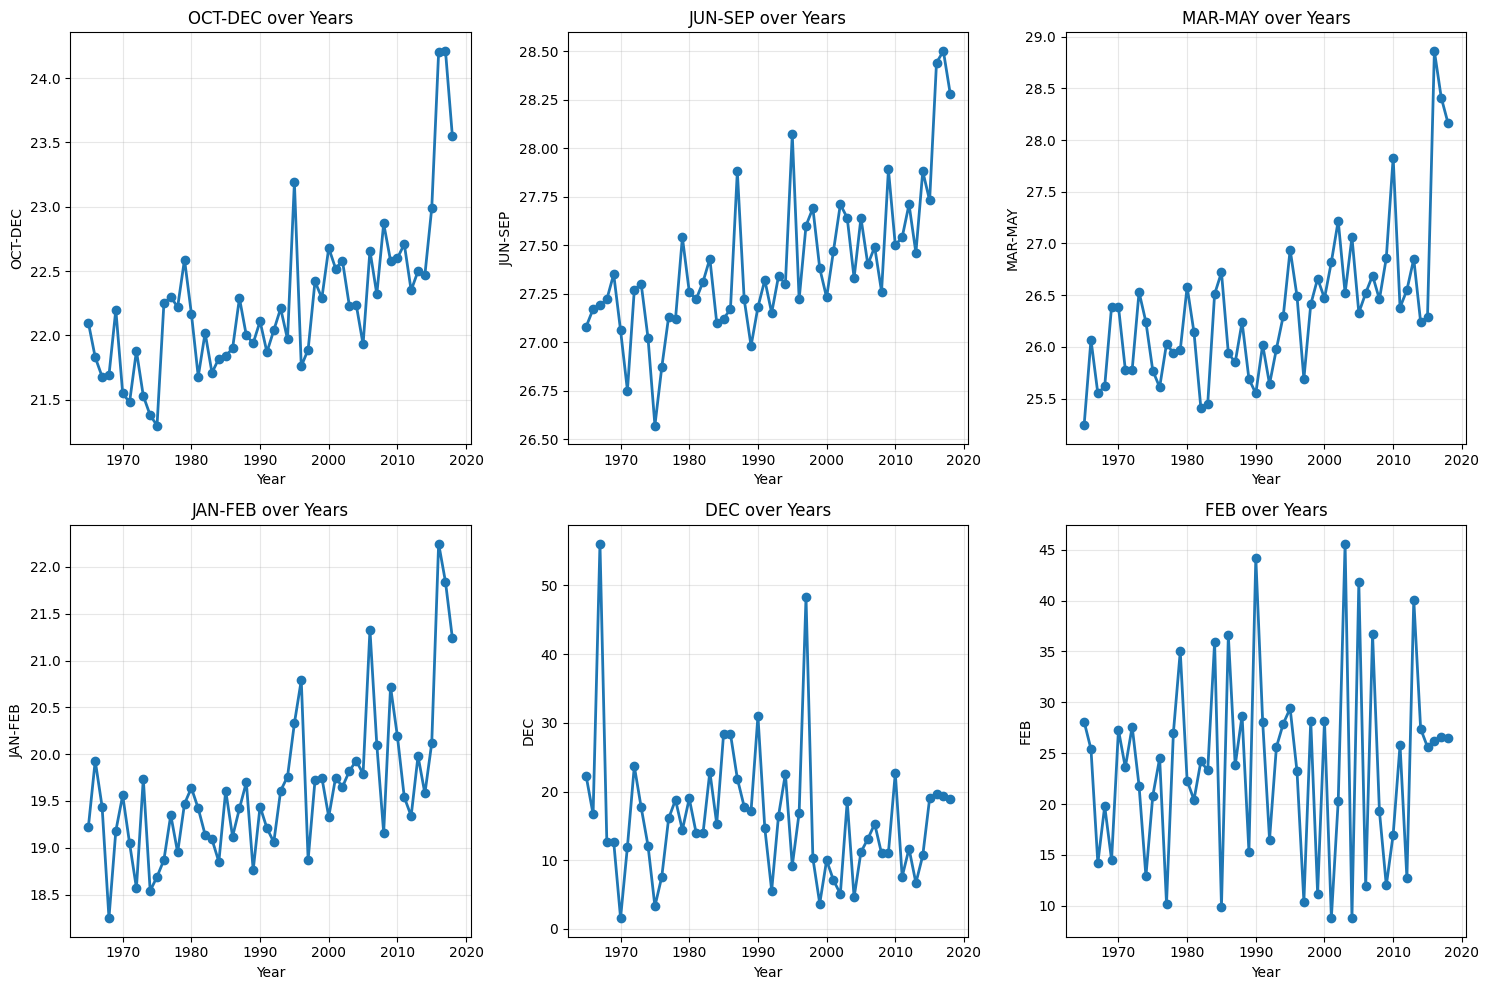


CROP-SPECIFIC FEATURE ANALYSIS

CROP: APPLES
Number of samples: 54
Yield range: 41399.00 - 100000.00
Average yield: 55999.28

Correlation with yield for this crop:
Value      1.000000
OCT-DEC    0.584130
JUN-SEP    0.537543
MAR-MAY    0.425638
JAN-FEB    0.420945
FEB        0.114251
DEC        0.057710
Name: Value, dtype: float64

CROP: APRICOTS
Number of samples: 54
Yield range: 27586.00 - 32500.00
Average yield: 29427.69

Correlation with yield for this crop:
Value      1.000000
DEC        0.098990
FEB        0.022278
MAR-MAY   -0.408280
JAN-FEB   -0.500912
OCT-DEC   -0.551432
JUN-SEP   -0.569169
Name: Value, dtype: float64

CROP: ARECA NUTS
Number of samples: 54
Yield range: 8288.00 - 14677.00
Average yield: 10840.87

Correlation with yield for this crop:
Value      1.000000
OCT-DEC    0.704465
JUN-SEP    0.683205
JAN-FEB    0.669668
MAR-MAY    0.635421
FEB        0.039414
DEC       -0.062718
Name: Value, dtype: float64

CROP: BANANAS
Number of samples: 54
Yield range: 119798.00 - 

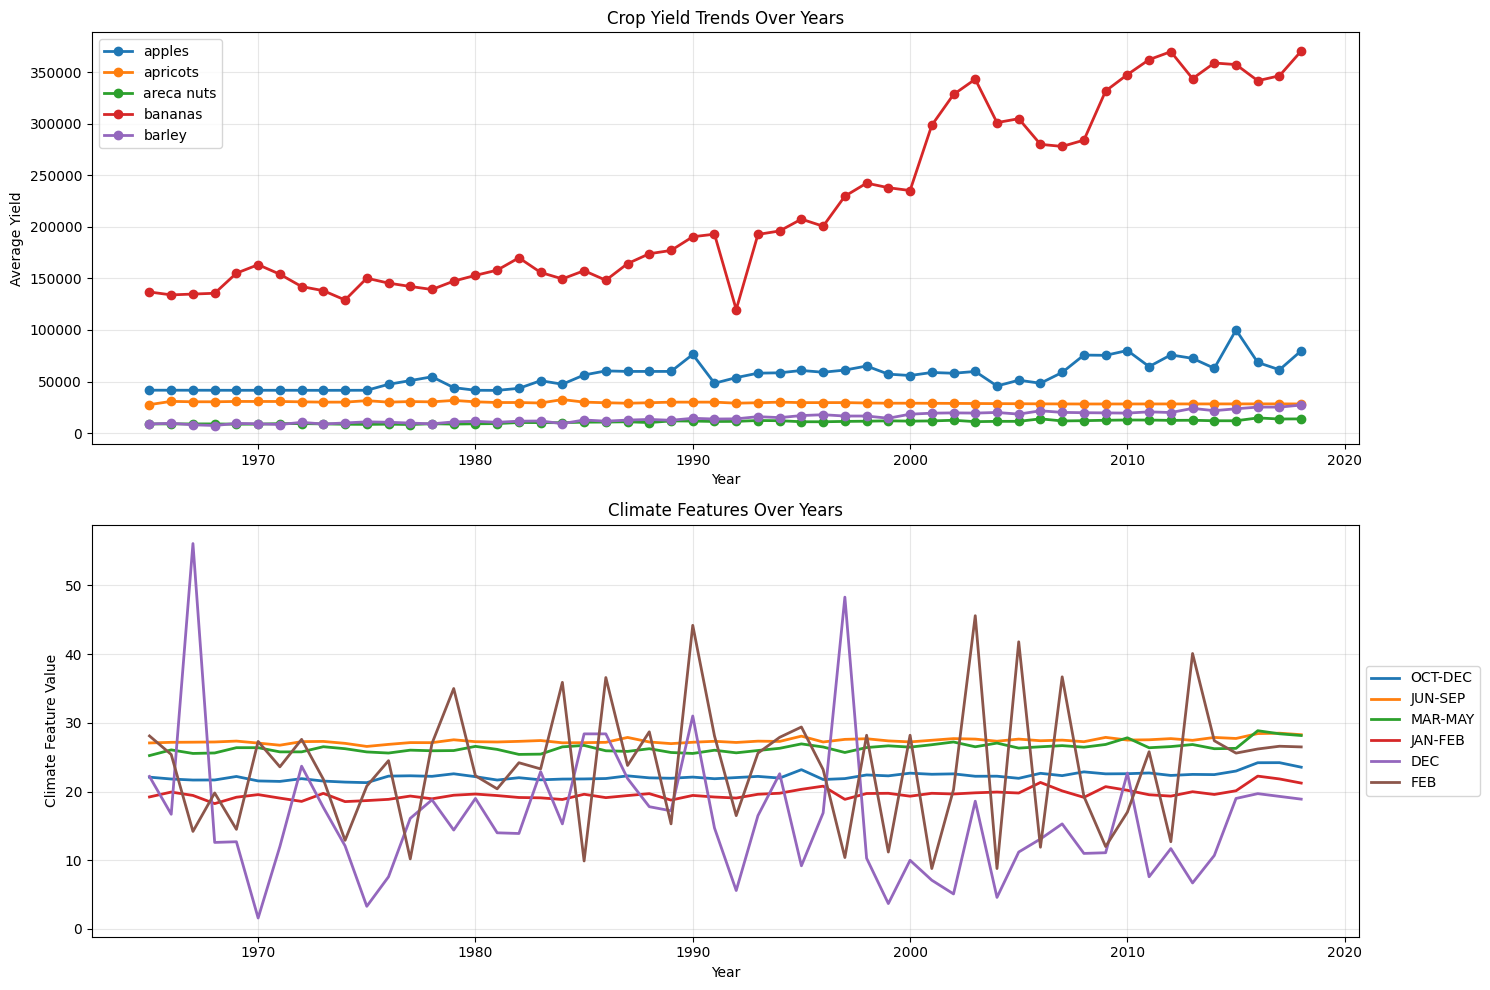


SUMMARY STATISTICS

MERGED DATASET SUMMARY:
----------------------
Total samples: 2646
Number of crops: 49
Years covered: 1965 - 2018
F-score features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

CROP COVERAGE:
--------------
crop_type
apples         54
apricots       54
areca nuts     54
bananas        54
barley         54
beans dry      54
beans green    54
cabbage        54
carrots        54
cashewnuts     54
Name: count, dtype: int64

DATA FILES CREATED:
-------------------
1. crop_fscore_merged_data.csv - Main merged dataset
2. crop_fscore_merged_complete.csv - Complete merged data
3. crop_fscore_aggregated.csv - Aggregated by crop-year
4. crop_fscore_wide_format.csv - Wide format (crops as columns)

FEATURE CORRELATION WITH YIELD:
------------------------------
Value      1.000000
JUN-SEP    0.095397
OCT-DEC    0.094843
MAR-MAY    0.090755
JAN-FEB    0.087231
FEB        0.007662
DEC       -0.020156


✅ Merging completed successfully!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== 1. LOAD AND PREPARE DATA =====================

# F-score selected features (from your output)
fscore_selected_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
print(f"F-score selected features: {fscore_selected_features}")

# Load climate data with selected features
# climate_fscore = climate_df_clean[['Year'] + fscore_selected_features].copy()

climate_fscore = climate_df_clean[['Year'] + final_selected_features].copy()


print("\nClimate data with F-score selected features:")
print(climate_fscore.head())
print(f"Shape: {climate_fscore.shape}")

# Load crop data
crop_data_clean = crop_df.copy()
crop_data_clean = crop_data_clean[['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha' ]].dropna()
crop_data_clean['Year'] = crop_data_clean['Year'].astype(int)

print("\nCrop data:")
print(crop_data_clean.head())
print(f"Shape: {crop_data_clean.shape}")

# ===================== 2. MERGE CROP DATA WITH F-SCORE FEATURES =====================

# Merge crop data with F-score selected climate features
merged_fscore_data = pd.merge(
    crop_data_clean,
    climate_fscore,
    on='Year',
    how='inner'
)

print("\nMerged dataset (crop + F-score selected features):")
print(merged_fscore_data.head())
print(f"Shape: {merged_fscore_data.shape}")
print(f"Columns: {merged_fscore_data.columns.tolist()}")

# ===================== 3. SAVE MERGED DATASET =====================

# Save the merged dataset
merged_fscore_data.to_csv('crop_fscore_merged_data.csv', index=False)
print("\n✅ Merged dataset saved to 'crop_fscore_merged_data.csv'")

# ===================== 4. EXPLORE MERGED DATA =====================

print("\n" + "="*60)
print("EXPLORATORY ANALYSIS OF MERGED DATA")
print("="*60)

# Summary statistics
print("\nBasic statistics of merged data:")
print(merged_fscore_data.describe())

# Check for missing values
print("\nMissing values in merged dataset:")
print(merged_fscore_data.isnull().sum())

# Summary by crop
print("\nCrop types in dataset:")
print(merged_fscore_data.groupby('crop_type').agg({
    'Value': ['count', 'mean', 'std', 'min', 'max'],
    'Year': ['min', 'max']
}))

# ===================== 5. CORRELATION ANALYSIS =====================

print("\n" + "="*60)
print("CORRELATION ANALYSIS WITH F-SCORE FEATURES")
print("="*60)

# Correlation between F-score features and crop yield
correlation_matrix = merged_fscore_data[['Value'] + fscore_selected_features].corr()
print("\nCorrelation with crop yield (Value):")
print(correlation_matrix['Value'].sort_values(ascending=False))

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation: Crop Yield and F-score Features')
plt.tight_layout()
plt.show()

# Pair plot of selected features
sns.pairplot(merged_fscore_data[['Value'] + fscore_selected_features],
             diag_kind='kde', height=2.5)
plt.suptitle('Pair Plot: F-score Features and Crop Yield', y=1.02)
plt.tight_layout()
plt.show()

# ===================== 6. FEATURE DISTRIBUTION ANALYSIS =====================

print("\n" + "="*60)
print("FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# Distribution of F-score features over years
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(fscore_selected_features):
    axes[i].plot(merged_fscore_data.groupby('Year')[feature].mean(),
                 marker='o', linewidth=2)
    axes[i].set_title(f'{feature} over Years')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(feature)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== 7. CROP-SPECIFIC FEATURE ANALYSIS =====================

print("\n" + "="*60)
print("CROP-SPECIFIC FEATURE ANALYSIS")
print("="*60)

# Select top 5 crops for detailed analysis
top_crops = merged_fscore_data.groupby('crop_type')['Value'].count().sort_values(ascending=False).head(5).index

for crop in top_crops:
    print(f"\n{'='*40}")
    print(f"CROP: {crop.upper()}")
    print('='*40)

    crop_data = merged_fscore_data[merged_fscore_data['crop_type'] == crop]
    print(f"Number of samples: {len(crop_data)}")
    print(f"Yield range: {crop_data['Value'].min():.2f} - {crop_data['Value'].max():.2f}")
    print(f"Average yield: {crop_data['Value'].mean():.2f}")

    # Correlation for this crop
    crop_corr = crop_data[['Value'] + fscore_selected_features].corr()['Value']
    print("\nCorrelation with yield for this crop:")
    print(crop_corr.sort_values(ascending=False))

# ===================== 8. CREATE FINAL DATASET =====================

print("\n" + "="*60)
print("CREATE FINAL DATASETS")
print("="*60)

# Dataset 1: All merged data
final_dataset_1 = merged_fscore_data.copy()

# Dataset 2: Aggregated by crop and year (average yield per crop-year)
final_dataset_2 = merged_fscore_data.groupby(['Year', 'crop_type']).agg({
    'Value': 'mean',
    'OCT-DEC': 'first',
    'JUN-SEP': 'first',
    'MAR-MAY': 'first',
    'JAN-FEB': 'first',
    'DEC': 'first',
    'FEB': 'first'
}).reset_index()

# Dataset 3: Wide format (each crop as separate column)
final_dataset_3 = merged_fscore_data.pivot_table(
    index='Year',
    columns='crop_type',
    values='Value',
    aggfunc='mean'
).reset_index()

# Save all datasets
final_dataset_1.to_csv('crop_fscore_merged_complete.csv', index=False)
final_dataset_2.to_csv('crop_fscore_aggregated.csv', index=False)
final_dataset_3.to_csv('crop_fscore_wide_format.csv', index=False)

print("\n✅ Datasets saved:")
print(f"1. crop_fscore_merged_complete.csv - Complete merged data ({final_dataset_1.shape})")
print(f"2. crop_fscore_aggregated.csv - Aggregated by crop-year ({final_dataset_2.shape})")
print(f"3. crop_fscore_wide_format.csv - Wide format ({final_dataset_3.shape})")

# ===================== 9. VISUALIZATION OF CROP YIELD TRENDS =====================

# Plot crop yield trends with climate features
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Crop yield trends for top crops
ax1 = axes[0]
for crop in top_crops[:5]:
    crop_data = merged_fscore_data[merged_fscore_data['crop_type'] == crop]
    crop_yearly = crop_data.groupby('Year')['Value'].mean()
    ax1.plot(crop_yearly.index, crop_yearly.values, label=crop, marker='o', linewidth=2)

ax1.set_xlabel('Year')
ax1.set_ylabel('Average Yield')
ax1.set_title('Crop Yield Trends Over Years')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Climate features over years
ax2 = axes[1]
for feature in fscore_selected_features:
    feature_yearly = merged_fscore_data.groupby('Year')[feature].mean()
    ax2.plot(feature_yearly.index, feature_yearly.values, label=feature, linewidth=2)

ax2.set_xlabel('Year')
ax2.set_ylabel('Climate Feature Value')
ax2.set_title('Climate Features Over Years')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== 10. SUMMARY STATISTICS =====================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"""
MERGED DATASET SUMMARY:
----------------------
Total samples: {len(merged_fscore_data)}
Number of crops: {merged_fscore_data['crop_type'].nunique()}
Years covered: {merged_fscore_data['Year'].min()} - {merged_fscore_data['Year'].max()}
F-score features: {fscore_selected_features}

CROP COVERAGE:
--------------
{merged_fscore_data['crop_type'].value_counts().head(10)}

DATA FILES CREATED:
-------------------
1. crop_fscore_merged_data.csv - Main merged dataset
2. crop_fscore_merged_complete.csv - Complete merged data
3. crop_fscore_aggregated.csv - Aggregated by crop-year
4. crop_fscore_wide_format.csv - Wide format (crops as columns)

FEATURE CORRELATION WITH YIELD:
------------------------------
{merged_fscore_data[['Value'] + fscore_selected_features].corr()['Value'].sort_values(ascending=False).to_string()}
""")

print("\n✅ Merging completed successfully!")

#Clustering

In [32]:
# ===================== 1. LOAD MERGED DATASET =====================

# Load the merged dataset (crop + F-score features)
merged_data = pd.read_csv('crop_fscore_merged_data.csv')

print("="*60)
print("LOADED MERGED DATASET")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Columns: {merged_data.columns.tolist()}")
print("\nFirst 5 rows:")
print(merged_data.head())

# ===================== 2. PREPARE DATA FOR CLUSTERING =====================

# Select features for clustering (F-score selected features)
fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']
print(f"\nFeatures used for clustering: {fscore_features}")

# Extract feature matrix
X = merged_data[fscore_features].copy()

# Handle missing values
X = X.fillna(X.mean())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=fscore_features)

print(f"\nFeature matrix shape: {X_scaled_df.shape}")
print("Feature statistics after scaling:")
print(X_scaled_df.describe())

LOADED MERGED DATASET
Dataset shape: (2646, 29)
Columns: ['Year', 'Item', 'Element', 'Value', 'crop_type', 'Nitrogen (N) kg/ha', 'Phosphorus (P) kg/ha', 'Potassium (K) kg/ha', 'SEP', 'MAR-MAY', 'Jan-Feb', 'JUN', 'OCT-DEC', 'Oct-Dec', 'MAR', 'DEC', 'MAY', 'JAN-FEB', 'AUG', 'APR', 'FEB', 'Mar-May', 'winter_avg', 'JUL', 'JAN', 'monsoon_avg', 'JUN-SEP', 'OCT', 'NOV']

First 5 rows:
   Year    Item Element  Value crop_type  Nitrogen (N) kg/ha  \
0  1965  Apples   Yield  41573    apples               46.33   
1  1966  Apples   Yield  41558    apples               85.55   
2  1967  Apples   Yield  41543    apples               94.41   
3  1968  Apples   Yield  41509    apples               77.99   
4  1969  Apples   Yield  41475    apples              156.02   

   Phosphorus (P) kg/ha  Potassium (K) kg/ha    SEP  MAR-MAY  ...   APR   FEB  \
0                 50.38                45.03  129.5    25.24  ...  45.1  28.1   
1                 44.48                10.98  143.9    26.07  ...  30.6 


DETERMINING OPTIMAL NUMBER OF CLUSTERS


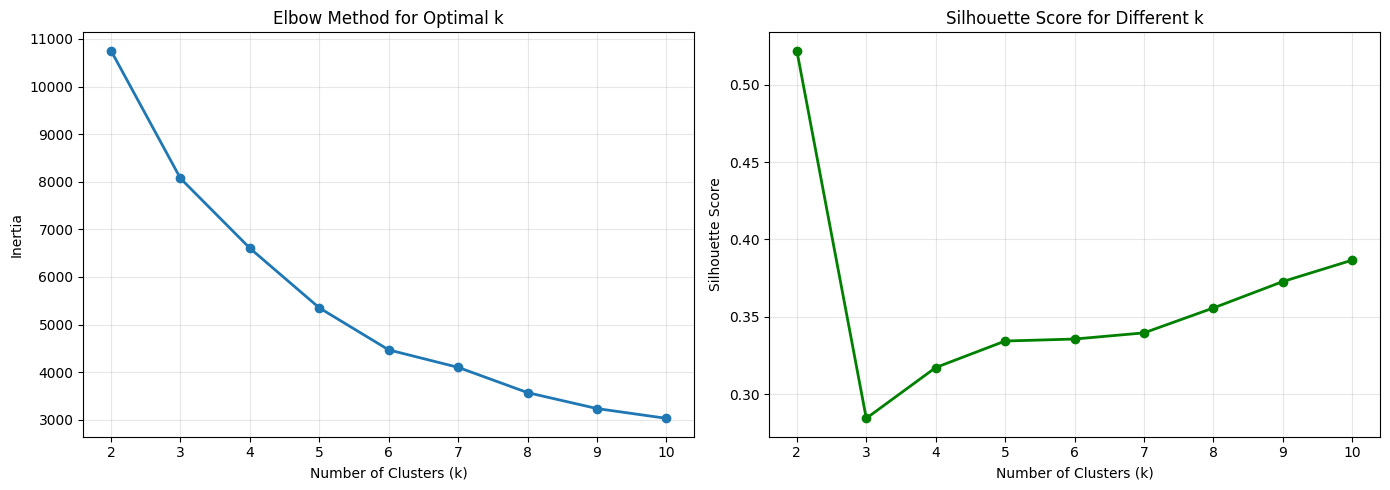

In [33]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Different k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




DETERMINING OPTIMAL NUMBER OF CLUSTERS


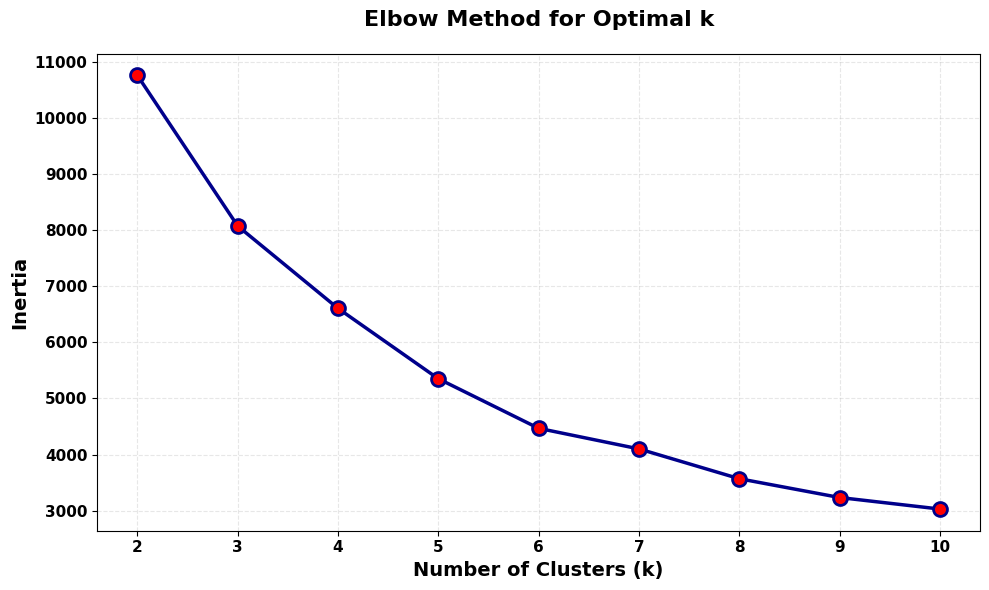


ELBOW METHOD RESULTS
  k=2: Inertia = 10,752
  k=3: Inertia = 8,071
  k=4: Inertia = 6,604
  k=5: Inertia = 5,351
  k=6: Inertia = 4,469
  k=7: Inertia = 4,102
  k=8: Inertia = 3,571
  k=9: Inertia = 3,236
  k=10: Inertia = 3,031


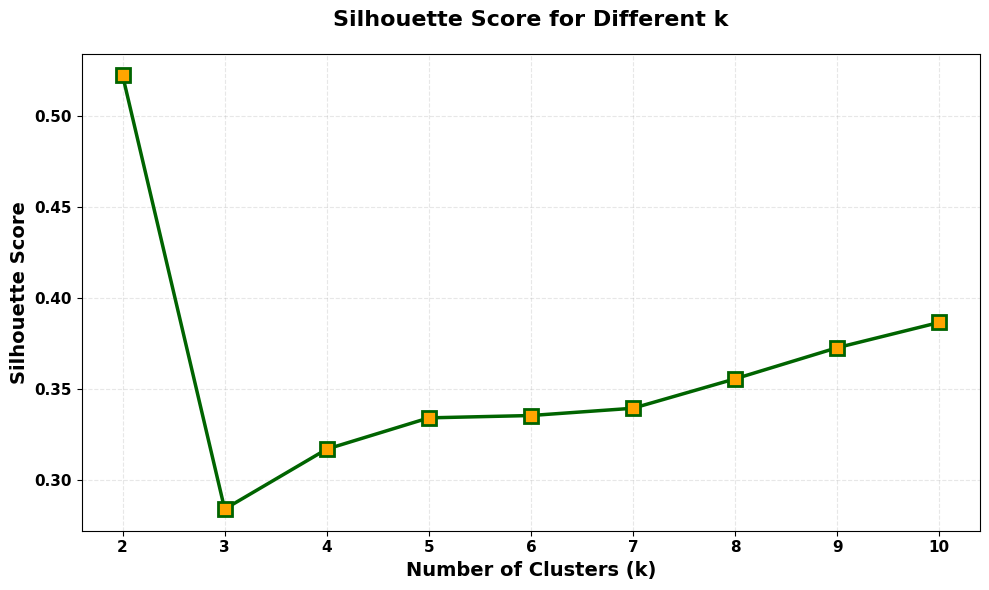


SILHOUETTE SCORE RESULTS
  k=2: Silhouette Score = 0.5221
  k=3: Silhouette Score = 0.2843
  k=4: Silhouette Score = 0.3171
  k=5: Silhouette Score = 0.3343
  k=6: Silhouette Score = 0.3356
  k=7: Silhouette Score = 0.3396
  k=8: Silhouette Score = 0.3557
  k=9: Silhouette Score = 0.3728
  k=10: Silhouette Score = 0.3866


In [34]:
# ===================== 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD) =====================

print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*60)

# Elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# ===================== PLOT 1: ELBOW METHOD (SEPARATE) =====================
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2.5, markersize=10,
         color='darkblue', markerfacecolor='red', markeredgewidth=2)

# Highlight the elbow point (k=3)
# elbow_k = 3
# elbow_idx = list(K_range).index(elbow_k)
# plt.plot(elbow_k, inertia[elbow_idx], 'o', color='red', markersize=15,
#          markerfacecolor='red', markeredgecolor='black', markeredgewidth=2)

# Add annotation for elbow point
# plt.annotate(f'Elbow Point (k={elbow_k})',
#              xy=(elbow_k, inertia[elbow_idx]),
#              xytext=(elbow_k + 1.5, inertia[elbow_idx] + 5000),
#              fontsize=12, fontweight='bold',
#              arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
plt.ylabel('Inertia', fontsize=14, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print elbow results
print("\n" + "="*60)
print("ELBOW METHOD RESULTS")
print("="*60)
for k, iner in zip(K_range, inertia):
    print(f"  k={k}: Inertia = {iner:,.0f}")
# print(f"\n{' '*4}→ Elbow point detected at: k = {elbow_k}")

# ===================== PLOT 2: SILHOUETTE SCORE (SEPARATE) =====================
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='s', linewidth=2.5, markersize=10,
         color='darkgreen', markerfacecolor='orange', markeredgewidth=2)

# Highlight the best silhouette score
# best_k = K_range[np.argmax(silhouette_scores)]
# best_score = max(silhouette_scores)
# best_idx = list(K_range).index(best_k)
# plt.plot(best_k, best_score, 'o', color='orange', markersize=15,
#          markerfacecolor='orange', markeredgecolor='black', markeredgewidth=2)

# Add annotation for best silhouette score
# plt.annotate(f'Best k={best_k} (Score: {best_score:.3f})',
#              xy=(best_k, best_score),
#              xytext=(best_k + 1.5, best_score - 0.02),
#              fontsize=12, fontweight='bold',
#              arrowprops=dict(arrowstyle='->', color='orange', lw=2))

plt.xlabel('Number of Clusters (k)', fontsize=14, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=14, fontweight='bold')
plt.title('Silhouette Score for Different k', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Print silhouette results
print("\n" + "="*60)
print("SILHOUETTE SCORE RESULTS")
print("="*60)
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: Silhouette Score = {score:.4f}")
# print(f"\n{' '*4}→ Best silhouette score: k={best_k} (Score: {best_score:.4f})")

In [35]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

In [36]:
# ===================== 4. METHOD 1: K-MEANS CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 1: K-MEANS CLUSTERING")
print("="*60)

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original data
merged_data['KMeans_Cluster'] = kmeans_labels

# Evaluate K-Means
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means Evaluation Metrics:")
print(f"  - Silhouette Score: {kmeans_silhouette:.4f}")
print(f"  - Calinski-Harabasz Score: {kmeans_calinski:.4f}")
print(f"  - Davies-Bouldin Score: {kmeans_davies:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

# Cluster centers
print("\nCluster Centers (scaled features):")
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=fscore_features
)
print(cluster_centers)


METHOD 1: K-MEANS CLUSTERING
K-Means Evaluation Metrics:
  - Silhouette Score: 0.2843
  - Calinski-Harabasz Score: 1278.0084
  - Davies-Bouldin Score: 1.2199

Cluster sizes:
0    1421
1     147
2    1078
Name: count, dtype: int64

Cluster Centers (scaled features):
    OCT-DEC   JUN-SEP   MAR-MAY   JAN-FEB       DEC       FEB
0 -0.619604 -0.629191 -0.564134 -0.558465  0.294459 -0.075848
1  2.956844  2.680294  2.942594  2.785231  0.333444  0.303189
2  0.413545  0.463894  0.342369  0.356354 -0.433620  0.058638



METHOD 2: DBSCAN CLUSTERING


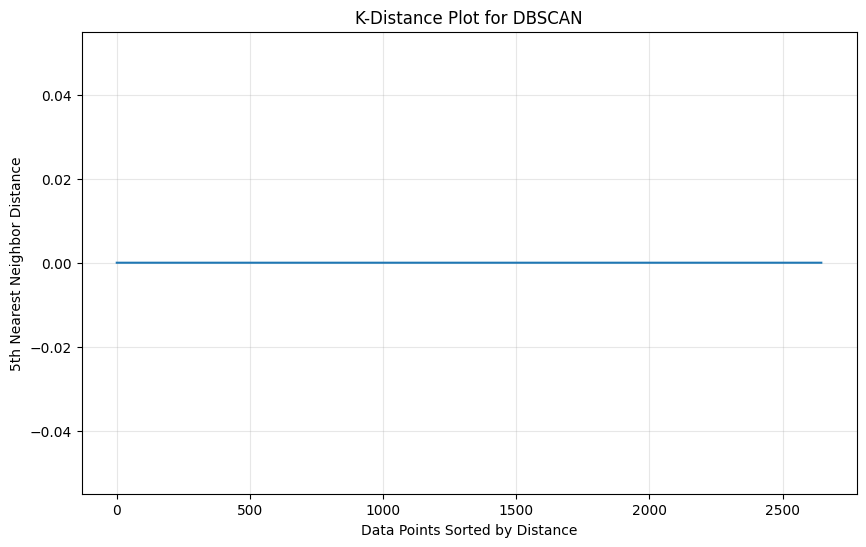

Testing DBSCAN with different parameters:
  eps=0.5, min_samples=3: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=5: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=7: clusters=54, noise=0, silhouette=1.0000
  eps=0.5, min_samples=10: clusters=54, noise=0, silhouette=1.0000
  eps=0.8, min_samples=3: clusters=47, noise=0, silhouette=0.9052
  eps=0.8, min_samples=5: clusters=47, noise=0, silhouette=0.9052
  eps=0.8, min_samples=7: clusters=47, noise=0, silhouette=0.9052
  eps=0.8, min_samples=10: clusters=47, noise=0, silhouette=0.9052
  eps=1.0, min_samples=3: clusters=39, noise=0, silhouette=0.7671
  eps=1.0, min_samples=5: clusters=39, noise=0, silhouette=0.7671
  eps=1.0, min_samples=7: clusters=39, noise=0, silhouette=0.7671
  eps=1.0, min_samples=10: clusters=39, noise=0, silhouette=0.7671
  eps=1.2, min_samples=3: clusters=29, noise=0, silhouette=0.5963
  eps=1.2, min_samples=5: clusters=29, noise=0, silhouette=0.5963
  eps=1.2, min_samples=7: clust

In [37]:
# ===================== 5. METHOD 2: DBSCAN CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 2: DBSCAN CLUSTERING")
print("="*60)

# Find optimal eps using k-distance plot
from sklearn.neighbors import NearestNeighbors

# Compute k-distance
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # 5th nearest neighbor

# Plot k-distance
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot for DBSCAN')
plt.grid(True, alpha=0.3)
plt.show()

# Try different eps values
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [3, 5, 7, 10]

best_dbscan_score = -1
best_dbscan_params = None
best_dbscan_labels = None

print("Testing DBSCAN with different parameters:")
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:  # Need at least 2 clusters for silhouette score
            try:
                score = silhouette_score(X_scaled, labels)
                if score > best_dbscan_score:
                    best_dbscan_score = score
                    best_dbscan_params = (eps, min_samples)
                    best_dbscan_labels = labels
                print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.4f}")
            except:
                print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise} - Cannot compute silhouette")
        else:
            print(f"  eps={eps}, min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}")

if best_dbscan_labels is not None:
    merged_data['DBSCAN_Cluster'] = best_dbscan_labels
    print(f"\nBest DBSCAN parameters: eps={best_dbscan_params[0]}, min_samples={best_dbscan_params[1]}")
    print(f"Best Silhouette Score: {best_dbscan_score:.4f}")
    print(f"Number of clusters: {len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)}")
    print(f"Number of noise points: {list(best_dbscan_labels).count(-1)}")
    print(f"Cluster sizes:")
    print(pd.Series(best_dbscan_labels).value_counts().sort_index())
else:
    print("\nNo suitable DBSCAN clustering found with silhouette score > 0")
    # Use default DBSCAN
    dbscan = DBSCAN(eps=1.0, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    merged_data['DBSCAN_Cluster'] = dbscan_labels
    print("Using default DBSCAN (eps=1.0, min_samples=5)")

In [38]:
# ===================== 6. METHOD 3: HIERARCHICAL CLUSTERING =====================

print("\n" + "="*60)
print("METHOD 3: HIERARCHICAL CLUSTERING")
print("="*60)

# Try different linkage methods and number of clusters
linkage_methods = ['ward', 'complete', 'average', 'single']
best_hierarchical_score = -1
best_hierarchical_params = None
best_hierarchical_labels = None

print("Testing Hierarchical Clustering with different parameters:")
for method in linkage_methods:
    for n_clusters in range(2, 8):
        hierarchical = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=method
        )
        labels = hierarchical.fit_predict(X_scaled)

        try:
            score = silhouette_score(X_scaled, labels)
            if score > best_hierarchical_score:
                best_hierarchical_score = score
                best_hierarchical_params = (method, n_clusters)
                best_hierarchical_labels = labels
            print(f"  method={method}, n_clusters={n_clusters}: silhouette={score:.4f}")
        except:
            print(f"  method={method}, n_clusters={n_clusters}: Cannot compute silhouette")

if best_hierarchical_labels is not None:
    merged_data['Hierarchical_Cluster'] = best_hierarchical_labels
    print(f"\nBest Hierarchical parameters: method={best_hierarchical_params[0]}, n_clusters={best_hierarchical_params[1]}")
    print(f"Best Silhouette Score: {best_hierarchical_score:.4f}")
    print(f"Cluster sizes:")
    print(pd.Series(best_hierarchical_labels).value_counts().sort_index())
else:
    # Use default hierarchical
    hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
    hierarchical_labels = hierarchical.fit_predict(X_scaled)
    merged_data['Hierarchical_Cluster'] = hierarchical_labels
    print("Using default hierarchical (n_clusters=3, linkage='ward')")



METHOD 3: HIERARCHICAL CLUSTERING
Testing Hierarchical Clustering with different parameters:
  method=ward, n_clusters=2: silhouette=0.5684
  method=ward, n_clusters=3: silhouette=0.2859
  method=ward, n_clusters=4: silhouette=0.3198
  method=ward, n_clusters=5: silhouette=0.3363
  method=ward, n_clusters=6: silhouette=0.3200
  method=ward, n_clusters=7: silhouette=0.3236
  method=complete, n_clusters=2: silhouette=0.5684
  method=complete, n_clusters=3: silhouette=0.4684
  method=complete, n_clusters=4: silhouette=0.2713
  method=complete, n_clusters=5: silhouette=0.2961
  method=complete, n_clusters=6: silhouette=0.2827
  method=complete, n_clusters=7: silhouette=0.2872
  method=average, n_clusters=2: silhouette=0.5221
  method=average, n_clusters=3: silhouette=0.4539
  method=average, n_clusters=4: silhouette=0.2841
  method=average, n_clusters=5: silhouette=0.2686
  method=average, n_clusters=6: silhouette=0.2744
  method=average, n_clusters=7: silhouette=0.2883
  method=single, n


HIERARCHICAL CLUSTERING DENDROGRAM


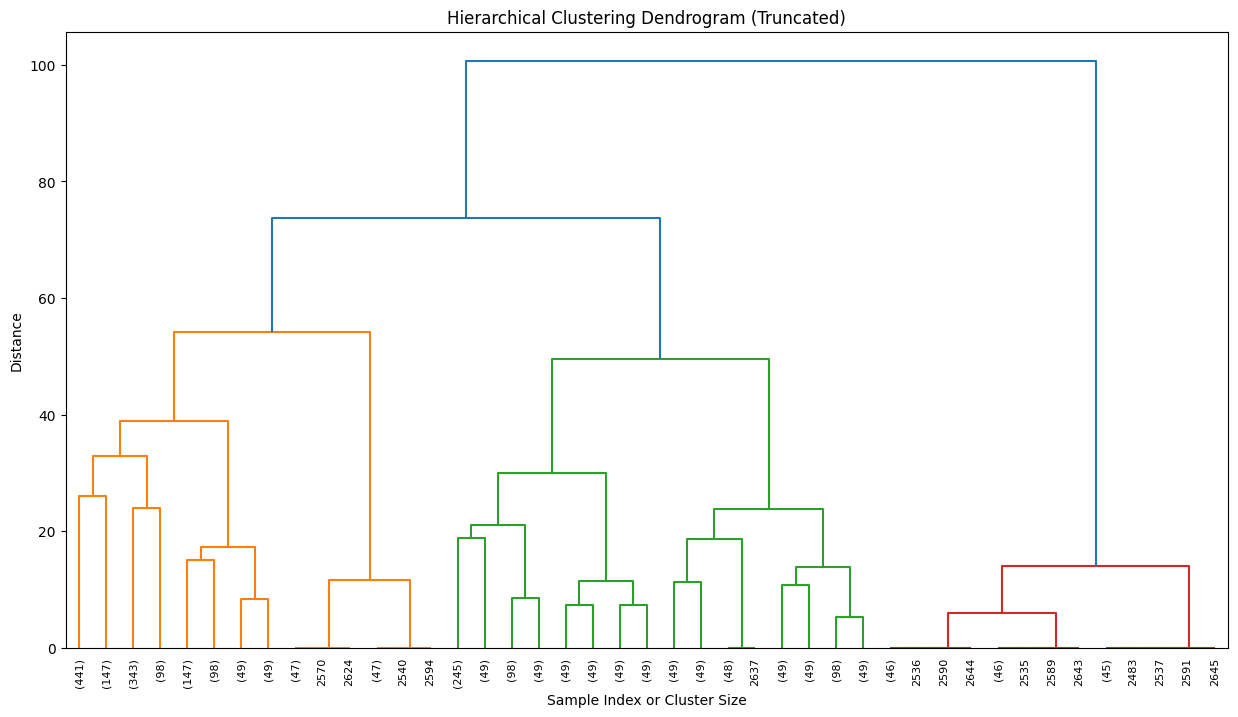

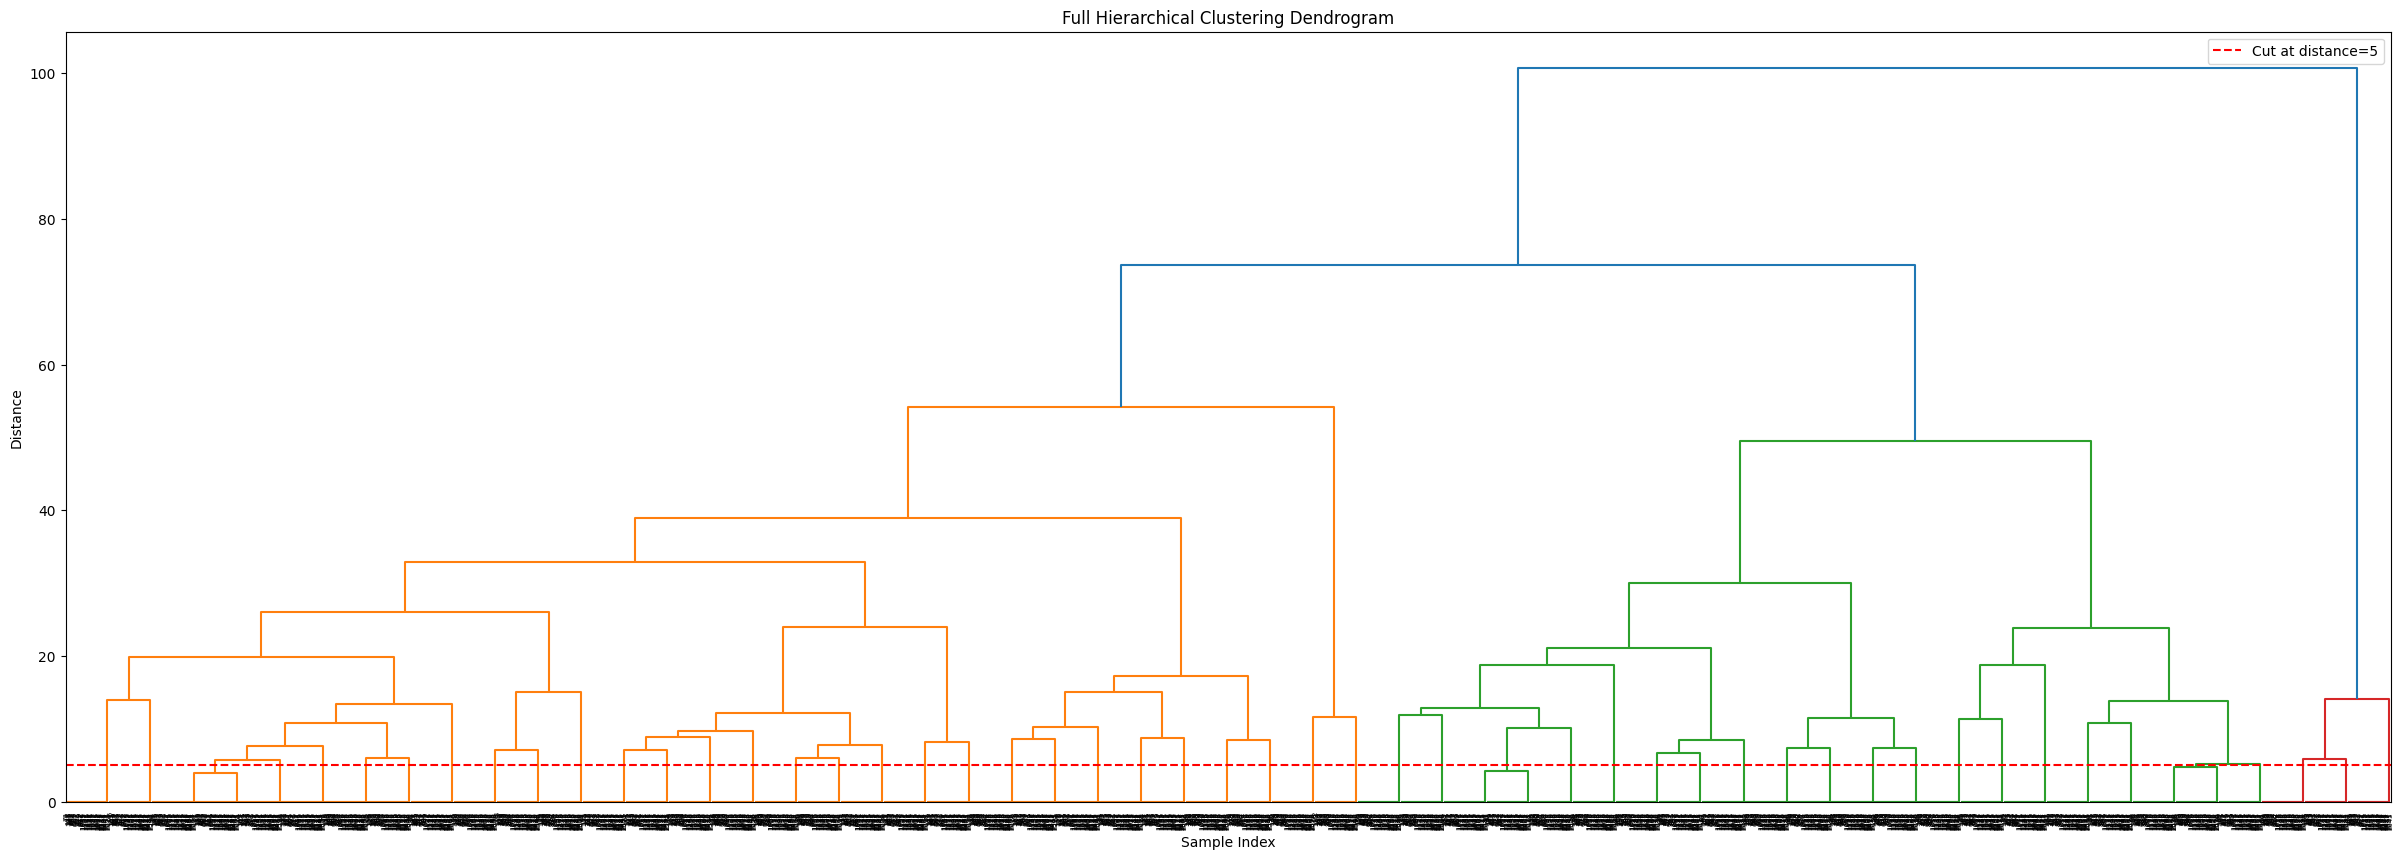

In [39]:
# ===================== 7. DENDROGRAM FOR HIERARCHICAL CLUSTERING =====================

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING DENDROGRAM")
print("="*60)

# Create linkage matrix
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='level',
           p=5)
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

# Full dendrogram
plt.figure(figsize=(30, 10))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title('Full Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=5, color='r', linestyle='--', label='Cut at distance=5')
plt.legend()
plt.show()


VISUALIZING CLUSTERS USING PCA


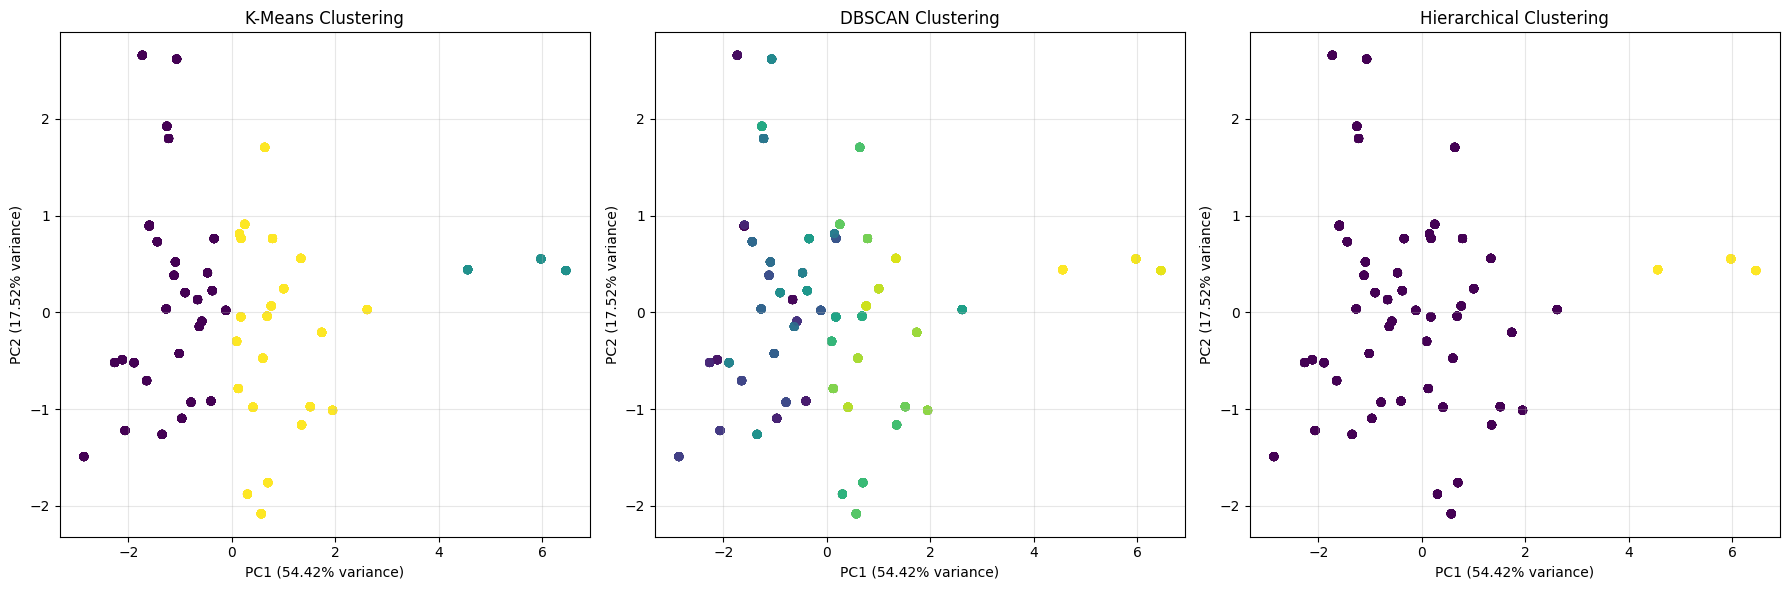

In [40]:
# ===================== 9. VISUALIZE CLUSTERS USING PCA =====================

print("\n" + "="*60)
print("VISUALIZING CLUSTERS USING PCA")
print("="*60)

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create subplots for each clustering method
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods = ['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster']
titles = ['K-Means Clustering', 'DBSCAN Clustering', 'Hierarchical Clustering']

for i, (method, title) in enumerate(zip(methods, titles)):
    # Get cluster labels
    if method == 'DBSCAN_Cluster':
        labels = merged_data[method]
        # Separate noise points
        is_noise = labels == -1
        noise_labels = labels[is_noise]
        cluster_labels = labels[~is_noise]
    else:
        labels = merged_data[method]
        is_noise = np.zeros(len(labels), dtype=bool)

    # Plot
    scatter = axes[i].scatter(X_pca[:, 0], X_pca[:, 1],
                             c=labels, cmap='viridis',
                             alpha=0.7, s=30)

    # Highlight noise points for DBSCAN
    if method == 'DBSCAN_Cluster' and np.any(is_noise):
        axes[i].scatter(X_pca[is_noise, 0], X_pca[is_noise, 1],
                       c='red', marker='x', s=50, label='Noise')

    axes[i].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    axes[i].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    axes[i].set_title(title)
    axes[i].grid(True, alpha=0.3)

    # Add legend for DBSCAN
    if method == 'DBSCAN_Cluster' and np.any(is_noise):
        axes[i].legend()

plt.tight_layout()
plt.show()


In [41]:
# ===================== 10. CLUSTER CHARACTERISTICS =====================

print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS (Using K-Means Results)")
print("="*60)

# Use K-Means clusters for analysis
cluster_analysis = merged_data.groupby('KMeans_Cluster').agg({
    'Value': ['mean', 'std', 'count'],
    'OCT-DEC': 'mean',
    'JUN-SEP': 'mean',
    'MAR-MAY': 'mean',
    'JAN-FEB': 'mean',
    'DEC': 'mean',
    'FEB': 'mean'
}).round(2)

print("Cluster characteristics:")
print(cluster_analysis)

# Crop distribution per cluster
crop_cluster_dist = pd.crosstab(merged_data['crop_type'], merged_data['KMeans_Cluster'])
print("\nCrop distribution across clusters:")
print(crop_cluster_dist)

# ===================== 11. SAVE CLUSTERED DATA =====================

# Save the data with cluster labels
merged_data.to_csv('crop_fscore_clustered_data.csv', index=False)
print("\n✅ Clustered data saved to 'crop_fscore_clustered_data.csv'")

# Save cluster analysis
cluster_analysis.to_csv('cluster_characteristics.csv')
print("✅ Cluster characteristics saved to 'cluster_characteristics.csv'")


CLUSTER CHARACTERISTICS (Using K-Means Results)
Cluster characteristics:
                    Value                  OCT-DEC JUN-SEP MAR-MAY JAN-FEB  \
                     mean        std count    mean    mean    mean    mean   
KMeans_Cluster                                                               
0                69410.17   86471.79  1421   21.88   27.17   25.96   19.19   
1               103895.61  127511.72   147   23.99   28.41   28.48   21.78   
2                89893.99  113671.83  1078   22.49   27.58   26.61   19.90   

                  DEC    FEB  
                 mean   mean  
KMeans_Cluster                
0               18.92  23.00  
1               19.30  26.43  
2               11.90  24.22  

Crop distribution across clusters:
KMeans_Cluster     0  1   2
crop_type                  
apples            29  3  22
apricots          29  3  22
areca nuts        29  3  22
bananas           29  3  22
barley            29  3  22
beans dry         29  3  22
beans green

In [42]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [43]:
merged_data

,Year,Item,Element,Value,crop_type,Nitrogen (N) kg/ha,Phosphorus (P) kg/ha,Potassium (K) kg/ha,SEP,MAR-MAY,...,winter_avg,JUL,JAN,monsoon_avg,JUN-SEP,OCT,NOV,KMeans_Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,1965,Apples,Yield,41573,apples,46.33,50.38,45.03,129.5,25.24,...,20.700000,270.1,11.8,177.125,27.08,34.0,18.2,0,0,0
1,1966,Apples,Yield,41558,apples,85.55,44.48,10.98,143.9,26.07,...,18.400000,252.5,13.1,196.925,27.17,56.1,51.0,0,1,0
2,1967,Apples,Yield,41543,apples,94.41,23.67,91.48,170.3,25.55,...,27.133333,305.6,11.1,221.050,27.19,40.6,12.1,0,2,0
3,1968,Apples,Yield,41509,apples,77.99,60.57,18.22,129.5,25.62,...,20.600000,309.9,29.4,200.450,27.22,67.1,21.8,0,3,0
4,1969,Apples,Yield,41475,apples,156.02,29.65,38.74,172.7,26.39,...,13.300000,317.8,12.7,223.525,27.35,55.0,35.8,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2014,Wheat,Yield,28395,wheat,116.25,12.75,78.44,188.0,26.24,...,19.100000,261.2,19.2,195.525,27.88,60.2,14.4,2,49,0
2642,2015,Wheat,Yield,29886,wheat,50.90,78.41,70.88,171.9,26.29,...,20.833333,284.5,17.9,219.625,27.73,73.1,29.4,2,50,0
2643,2016,Wheat,Yield,31775,wheat,173.76,26.96,37.09,169.2,28.86,...,21.166667,287.7,17.6,221.675,28.44,76.0,29.2,1,51,1
2644,2017,Wheat,Yield,31538,wheat,74.57,56.43,26.56,173.4,28.41,...,21.366667,294.8,18.2,224.425,28.50,78.1,28.5,1,52,1


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# ===================== 1. LOAD CLUSTERED DATA =====================

# Load the clustered data
merged_data = pd.read_csv('crop_fscore_clustered_data.csv')

print("="*60)
print("LOADING CLUSTERED DATA")
print("="*60)
print(f"Dataset shape: {merged_data.shape}")
print(f"Cluster distribution:\n{merged_data['KMeans_Cluster'].value_counts()}")

# ===================== 2. PREPARE DATA FOR EACH CLUSTER =====================

# Define F-score features
fscore_features = ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB']

# Encode crop type
le = LabelEncoder()
merged_data['crop_type_encoded'] = le.fit_transform(merged_data['crop_type'])

# Add cluster as feature
merged_data['cluster'] = merged_data['KMeans_Cluster']

# Prepare features and target
X = merged_data[fscore_features + ['crop_type_encoded', 'cluster']].copy()
# y = merged_data['Value'].copy()
# y = crop_df[crop_df['Element'] == 'Yield']['Value']
y = merged_data[merged_data['Element'] == 'Yield']['Value']

# Handle missing values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)
print(f"Features: {X.columns.tolist()}")
print(f"Total samples: {len(X)}")

# ===================== 3. SPLIT DATA BY CLUSTER =====================

# Split data for Cluster 0
cluster_0_mask = merged_data['KMeans_Cluster'] == 0
X0 = X[cluster_0_mask]
y0 = y[cluster_0_mask]

# Split data for Cluster 1
cluster_1_mask = merged_data['KMeans_Cluster'] == 1
X1 = X[cluster_1_mask]
y1 = y[cluster_1_mask]

# Split data for Cluster 1
cluster_2_mask = merged_data['KMeans_Cluster'] == 2
X2 = X[cluster_2_mask]
y2 = y[cluster_2_mask]

print("\n" + "="*60)
print("CLUSTER DATA SPLIT")
print("="*60)
print(f"Cluster 0 samples: {len(X0)}")
print(f"Cluster 1 samples: {len(X1)}")
print(f"Cluster 2 samples: {len(X2)}")

# ===================== 4. TRAIN-TEST SPLIT FOR EACH CLUSTER =====================

# Split Cluster 0
X0_train, X0_test, y0_train, y0_test = train_test_split(
    X0, y0, test_size=0.3, random_state=42
)

# Split Cluster 1
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.3, random_state=42
)

# Split Cluster 2
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42
)

print("\n" + "="*60)
print("TRAIN-TEST SPLIT RESULTS")
print("="*60)
print("\nCluster 0:")
print(f"  Train size: {len(X0_train)} ({len(X0_train)/len(X0)*100:.1f}%)")
print(f"  Test size: {len(X0_test)} ({len(X0_test)/len(X0)*100:.1f}%)")

print("\nCluster 1:")
print(f"  Train size: {len(X1_train)} ({len(X1_train)/len(X1)*100:.1f}%)")
print(f"  Test size: {len(X1_test)} ({len(X1_test)/len(X1)*100:.1f}%)")

print("\nCluster 2:")
print(f"  Train size: {len(X2_train)} ({len(X2_train)/len(X2)*100:.1f}%)")
print(f"  Test size: {len(X2_test)} ({len(X2_test)/len(X2)*100:.1f}%)")

# ===================== 5. SCALE FEATURES =====================

# Scale features for Cluster 0
scaler0 = StandardScaler()
X0_train_scaled = scaler0.fit_transform(X0_train)
X0_test_scaled = scaler0.transform(X0_test)

# Scale features for Cluster 1
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Scale features for Cluster 2
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("\nFeature scaling completed!")

# ===================== 6. DEFINE MODELS =====================

models = {
    'CatBoost': CatBoostRegressor(verbose=0, random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

# ===================== 7. TRAIN AND EVALUATE MODELS ON CLUSTER 0 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 0")
print("="*60)

results_cluster0 = {}

for name, model in models.items():
    # Train
    model.fit(X0_train_scaled, y0_train)

    # Predict
    y0_train_pred = model.predict(X0_train_scaled)
    y0_test_pred = model.predict(X0_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y0_train, y0_train_pred)
    test_r2 = r2_score(y0_test, y0_test_pred)
    train_mae = mean_absolute_error(y0_train, y0_train_pred)
    test_mae = mean_absolute_error(y0_test, y0_test_pred)
    train_mse = mean_squared_error(y0_train, y0_train_pred)
    test_mse = mean_squared_error(y0_test, y0_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster0[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 8. TRAIN AND EVALUATE MODELS ON CLUSTER 1 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 1")
print("="*60)

results_cluster1 = {}

for name, model in models.items():
    # Train
    model.fit(X1_train_scaled, y1_train)

    # Predict
    y1_train_pred = model.predict(X1_train_scaled)
    y1_test_pred = model.predict(X1_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y1_train, y1_train_pred)
    test_r2 = r2_score(y1_test, y1_test_pred)
    train_mae = mean_absolute_error(y1_train, y1_train_pred)
    test_mae = mean_absolute_error(y1_test, y1_test_pred)
    train_mse = mean_squared_error(y1_train, y1_train_pred)
    test_mse = mean_squared_error(y1_test, y1_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster1[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 9. TRAIN AND EVALUATE MODELS ON CLUSTER 2 =====================

print("\n" + "="*60)
print("MODEL PERFORMANCE ON CLUSTER 2")
print("="*60)

results_cluster2 = {}

for name, model in models.items():
    # Train
    model.fit(X2_train_scaled, y2_train)

    # Predict
    y2_train_pred = model.predict(X2_train_scaled)
    y2_test_pred = model.predict(X2_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y2_train, y2_train_pred)
    test_r2 = r2_score(y2_test, y2_test_pred)
    train_mae = mean_absolute_error(y2_train, y2_train_pred)
    test_mae = mean_absolute_error(y2_test, y2_test_pred)
    train_mse = mean_squared_error(y2_train, y2_train_pred)
    test_mse = mean_squared_error(y2_test, y2_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    results_cluster1[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_MSE': train_mse,
        'Test_MSE': test_mse,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse
    }

    print(f"\n{name}:")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Train MAE: {train_mae:.2f}")
    print(f"  Test MAE: {test_mae:.2f}")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")

# ===================== 10. COMPARE RESULTS =====================

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 0")
print("="*60)

comparison0 = pd.DataFrame(results_cluster0).T
print(comparison0[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 1")
print("="*60)

comparison1 = pd.DataFrame(results_cluster1).T
print(comparison1[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

print("\n" + "="*60)
print("COMPARISON OF MODELS - CLUSTER 2")
print("="*60)

comparison2 = pd.DataFrame(results_cluster2).T
print(comparison2[['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE']].round(4))

# ===================== 11. FIND BEST MODEL FOR EACH CLUSTER =====================

print("\n" + "="*60)
print("BEST MODEL FOR EACH CLUSTER")
print("="*60)

# Cluster 0 - Best model by Test R²
best_model0 = comparison0['Test_R2'].idxmax()
best_r2_0 = comparison0.loc[best_model0, 'Test_R2']
best_rmse0 = comparison0.loc[best_model0, 'Test_RMSE']

print(f"\nCluster 0:")
print(f"  Best Model: {best_model0}")
print(f"  Test R²: {best_r2_0:.4f}")
print(f"  Test RMSE: {best_rmse0:.2f}")

# Cluster 1 - Best model by Test R²
best_model1 = comparison1['Test_R2'].idxmax()
best_r2_1 = comparison1.loc[best_model1, 'Test_R2']
best_rmse1 = comparison1.loc[best_model1, 'Test_RMSE']

print(f"\nCluster 1:")
print(f"  Best Model: {best_model1}")
print(f"  Test R²: {best_r2_1:.4f}")
print(f"  Test RMSE: {best_rmse1:.2f}")

# Cluster 2 - Best model by Test R²
best_model2 = comparison2['Test_R2'].idxmax()
best_r2_2 = comparison2.loc[best_model2, 'Test_R2']
best_rmse2 = comparison2.loc[best_model2, 'Test_RMSE']

print(f"\nCluster 1:")
print(f"  Best Model: {best_model2}")
print(f"  Test R²: {best_r2_2:.4f}")
print(f"  Test RMSE: {best_rmse2:.2f}")

# ===================== 12. OVERALL BEST MODEL =====================

# Combine results for both clusters
all_results = {}

for name in models.keys():
    # Average performance across clusters
    avg_test_r2 = (results_cluster0[name]['Test_R2'] + results_cluster1[name]['Test_R2'] + results_cluster2[name]['Test_R2']) / 3
    avg_test_rmse = (results_cluster0[name]['Test_RMSE'] + results_cluster1[name]['Test_RMSE'] + results_cluster2[name]['Test_RMSE']) / 3

    all_results[name] = {
        'Avg_Test_R2': avg_test_r2,
        'Avg_Test_RMSE': avg_test_rmse,
        'Cluster0_R2': results_cluster0[name]['Test_R2'],
        'Cluster1_R2': results_cluster1[name]['Test_R2'],
        'Cluster0_RMSE': results_cluster0[name]['Test_RMSE'],
        'Cluster1_RMSE': results_cluster1[name]['Test_RMSE']
    }

overall_comparison = pd.DataFrame(all_results).T
print("\n" + "="*60)
print("OVERALL MODEL COMPARISON (Average Across Clusters)")
print("="*60)
print(overall_comparison[['Avg_Test_R2', 'Avg_Test_RMSE', 'Cluster0_R2', 'Cluster1_R2']].round(4))

# Overall best model
best_overall = overall_comparison['Avg_Test_R2'].idxmax()
print(f"\n🏆 Overall Best Model: {best_overall}")
print(f"   Average Test R²: {overall_comparison.loc[best_overall, 'Avg_Test_R2']:.4f}")
print(f"   Average Test RMSE: {overall_comparison.loc[best_overall, 'Avg_Test_RMSE']:.2f}")

# ===================== 13. TRAIN FINAL MODEL ON FULL DATA =====================

print("\n" + "="*60)
print("TRAINING BEST MODEL ON FULL DATASET")
print("="*60)

# Get the best model
if best_overall == 'CatBoost':
    final_model = CatBoostRegressor(verbose=0, random_state=42)
elif best_overall == 'XGBoost':
    final_model = XGBRegressor(random_state=42, verbosity=0)
elif best_overall == 'RandomForest':
    final_model = RandomForestRegressor(random_state=42, n_jobs=-1)
elif best_overall == 'LightGBM':
    final_model = LGBMRegressor(random_state=42, verbose=-1)
else:
    final_model = GradientBoostingRegressor(random_state=42)

# Scale all data
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X)
y_final = y

# Train on full data
final_model.fit(X_scaled_final, y_final)

print(f"✅ {best_overall} trained on full dataset ({len(X)} samples)")
print(f"   Features used: {X.columns.tolist()}")

print("\n✅ Train-test split and model evaluation completed successfully!")

LOADING CLUSTERED DATA
Dataset shape: (2646, 32)
Cluster distribution:
KMeans_Cluster
0    1421
2    1078
1     147
Name: count, dtype: int64

DATA PREPARATION
Features: ['OCT-DEC', 'JUN-SEP', 'MAR-MAY', 'JAN-FEB', 'DEC', 'FEB', 'crop_type_encoded', 'cluster']
Total samples: 2646

CLUSTER DATA SPLIT
Cluster 0 samples: 1421
Cluster 1 samples: 147
Cluster 2 samples: 1078

TRAIN-TEST SPLIT RESULTS

Cluster 0:
  Train size: 994 (70.0%)
  Test size: 427 (30.0%)

Cluster 1:
  Train size: 102 (69.4%)
  Test size: 45 (30.6%)

Cluster 2:
  Train size: 754 (69.9%)
  Test size: 324 (30.1%)

Feature scaling completed!

MODEL PERFORMANCE ON CLUSTER 0

CatBoost:
  Train R²: 0.9923
  Test R²: 0.9362
  Train MAE: 5231.20
  Test MAE: 10285.50
  Train RMSE: 7764.73
  Test RMSE: 20512.67

XGBoost:
  Train R²: 0.9996
  Test R²: 0.9345
  Train MAE: 1124.27
  Test MAE: 10016.81
  Train RMSE: 1669.24
  Test RMSE: 20775.35

RandomForest:
  Train R²: 0.9922
  Test R²: 0.9443
  Train MAE: 3435.26
  Test MAE: 86

KeyError: "None of [Index(['Train_R2', 'Test_R2', 'Train_RMSE', 'Test_RMSE'], dtype='object')] are in the [columns]"

In [45]:
print(y.describe())

count      2646.000000
mean      79671.286092
std      101513.079735
min         382.000000
25%       10210.500000
50%       52940.000000
75%      109048.000000
max      765328.000000
Name: Value, dtype: float64


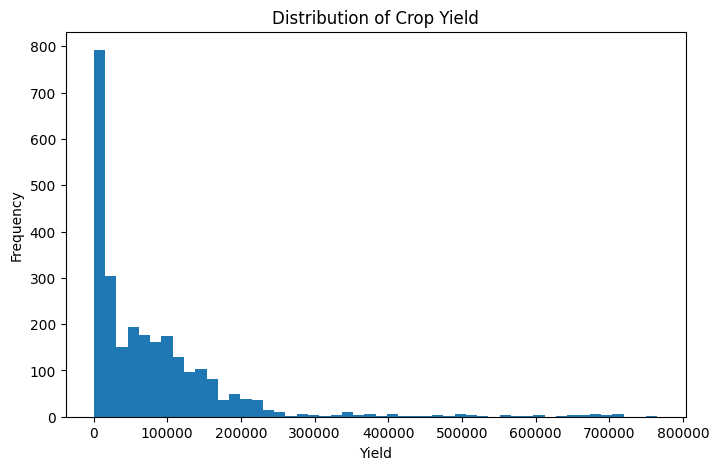

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y, bins=50)
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield")
plt.show()

In [47]:
print(crop_df['Element'].value_counts())
print(crop_df['Unit'].value_counts())

Element
Yield    2842
Name: count, dtype: int64
Unit
hg/ha    2842
Name: count, dtype: int64


In [48]:
print(
    crop_df.groupby(['Element', 'Unit'])['Value']
    .agg(['count', 'min', 'median', 'max'])
)

               count  min   median     max
Element Unit                              
Yield   hg/ha   2842  382  54297.0  801984
